In [1]:
import cornac
from cornac.data import Reader
from cornac.datasets import movielens
from cornac.data import Dataset, FeatureModality
from cornac.eval_methods import RatioSplit, StratifiedSplit
from cornac.metrics import RMSE, AUC, NDCG, Precision, Recall
from cornac.models import MF, ItemKNN, UserKNN, NMF, BPR, LightGCN, SVD, MostPop, VAECF
import pandas as pd
import numpy as np
import random
import math
from collections import OrderedDict
import seaborn as sns
import matplotlib.pyplot as plt

/Users/tahsinalamgirkheya/anaconda3/envs/cornac/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
reader = Reader()
rating_data_pd = pd.read_csv(
    "./cornac/data_c/ml-100k/indexed_interactions.csv",
    sep="\t",
    header=None,
    names=["userID", "itemID", "Rating", "Timestamp"],
)
rating_data = rating_data_pd.to_numpy()
rating_data.__len__()
rating_data_pd

,userID,itemID,Rating,Timestamp
0,0,0,3,881250949
1,1,1,3,891717742
2,2,2,1,878887116
3,3,3,2,880606923
4,4,4,1,886397596
...,...,...,...,...
99282,875,173,3,880175444
99283,708,247,5,879795543
99284,37,982,1,874795795
99285,58,442,2,882399156


In [3]:
df_m = pd.read_csv(
    "./cornac/data_c/ml-100K/u.item",
    sep="|",
    names=[
        "movieID",
        "Name",
        "Date",
        "Video_Date",
        "IMDB_URL",
        "unknown",
        "Action",
        "Adventure",
        "Animation",
        "Children's",
        "Comedy",
        "Crime",
        "Documentary",
        "Drama",
        "Fantasy",
        "Film-Noir",
        "Horror",
        "Musical",
        "Mystery",
        "Romance",
        "Sci-Fi",
        "Thriller",
        "War",
        "Western",
    ],
    header=None,
    encoding="latin-1",
)
print(df_m.shape)
df_m = df_m[
    [
        "movieID",
        "Action",
        "Adventure",
        "Animation",
        "Children's",
        "Comedy",
        "Crime",
        "Documentary",
        "Drama",
        "Fantasy",
        "Film-Noir",
        "Horror",
        "Musical",
        "Mystery",
        "Romance",
        "Sci-Fi",
        "Thriller",
        "War",
        "Western",
    ]
]

df_movies_mapped = pd.read_csv(
    "./cornac/data_c/ml-100K/i_id_mapping.csv",
    sep="\t",
    names=["movieID", "itemID"],
    header=None,
    encoding="latin-1",
)
movies = pd.merge(df_m, df_movies_mapped, how="inner", on="movieID")
movies

(1682, 24)


,movieID,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,itemID
0,1,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,24
1,2,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,147
2,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,233
3,4,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,47
4,5,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1344,1592,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1305
1345,1597,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1324
1346,1598,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1319
1347,1615,1,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1341


In [4]:
movies = movies.drop(columns=["movieID"])

In [5]:
movies = movies.sort_values(by="itemID")

In [6]:
movies

,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,itemID
240,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
300,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,1
375,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,2
50,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,1,3
344,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1248,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1344
1192,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1345
1176,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1346
1261,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1347


In [7]:

unique_genres = [
    "Action",
    "Thriller",
    "Romance",
    "Western",
    "Children's",
    "Mystery",
    "Fantasy",
    "Film-Noir",
    "Documentary",
    "Comedy",
    "Adventure",
    "Sci-Fi",
    "Horror",
    "Crime",
    "Musical",
    "War",
    "Animation",
    "Drama",
]
genre = movies[unique_genres]
item_features_numpy = genre.to_numpy()

users = pd.read_csv("./cornac/data_c/ml-100k/u_id_mapping.csv", sep="\t")

users = users.sort_values(by="userID")

users = users.drop(columns=users.columns[0])
gender_map = {"M": 0, "F": 1}
users["Gender"] = users["Gender"].map(gender_map)
user_features_numpy = users.to_numpy()
users

,Gender,userID
0,0,0
1,1,1
2,0,2
3,0,3
4,0,4
...,...,...
938,1,938
939,0,939
940,1,940
941,1,941


In [8]:
def create_genre_column(r):
    all_genres = [g for g in unique_genres if r[g] == 1]
    return "|".join(all_genres)


movies["genres"] = movies.apply(create_genre_column, axis=1)
movies

,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,itemID,genres
240,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Comedy
300,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,1,Thriller|Mystery|Film-Noir|Crime
375,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,2,Children's|Comedy
50,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,1,3,Romance|Western|War|Drama
344,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,4,Crime|Drama
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1248,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1344,Drama
1192,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1345,Comedy
1176,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1346,Drama
1261,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1347,Drama


In [9]:
dataset = rating_data
unique_genres.__len__()

18

In [10]:
# inter_movies
# unique_iids = inter_movies['userID'].unique()
# unique_iids.__len__()
# # movies = movies[movies['itemID'].isin(unique_iids)]
user_features_numpy[:, 0]
# item_features_numpy[0]

array([0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,

In [11]:
rating_data_pd

,userID,itemID,Rating,Timestamp
0,0,0,3,881250949
1,1,1,3,891717742
2,2,2,1,878887116
3,3,3,2,880606923
4,4,4,1,886397596
...,...,...,...,...
99282,875,173,3,880175444
99283,708,247,5,879795543
99284,37,982,1,874795795
99285,58,442,2,882399156


In [12]:
alpha_values = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]


In [13]:

ratio_split = StratifiedSplit(
    data=dataset,
    test_size=0.2,
    rating_threshold=0,
    val_size=0.1,
    seed=123,
    verbose=True,
    chrono=True,
    user_features=user_features_numpy[:, 0],
    item_features=item_features_numpy,
    exclude_unknowns=False,
)
rec_50 = cornac.metrics.Recall(k=50)
ndcg_50 = cornac.metrics.NDCG(k=50)
auc = cornac.metrics.AUC()
prec = cornac.metrics.Precision(k=50)
hr = cornac.metrics.HitRatio(k=50)
mrr = cornac.metrics.MRR()
map = cornac.metrics.MAP()
f1 = cornac.metrics.FMeasure(k=50)


models = []
x=[]
alpha_values = [0,0.1,0.2, 0.3, 0.4, 0.5, 0.6 ]
# alpha_values = [0]
for i in range(len(alpha_values)):
    # learning
    models.append(
        MF(
            k=20,
            seed=123,
            name=f"a={alpha_values[i]} mf",
            backend="pytorch",
            verbose=True,
            optimizer="adam",batch_size=128,
            alpha=alpha_values[i],
            learning_rate=0.001,
            top_k=50, max_iter=20,run_mode="bce",
            # early_stopping=True
        )
    )
 
 

cornac.Experiment(
    ratio_split, models=models, metrics=[rec_50, ndcg_50, auc, prec, hr, mrr, map, f1]
).run()

# - best epoch = 10, stopped epoch = 20
# - best monitored value = 0.108919 (delta = -0.001787)


rating_threshold = 0.0
exclude_unknowns = False
::::::::
OrderedDict()
OrderedDict()
::::::::
---
Training data:
(array([  0,   0,   0, ..., 942, 942, 942]), array([  0,   1,   2, ..., 880, 632, 261]), array([4., 4., 4., ..., 1., 5., 4.]))
Number of users = 943
Number of items = 1348
Number of ratings = 68674
Max rating = 5.0
Min rating = 1.0
Global mean = 3.6
Global mean Imolicit= 1.0
::::::::
OrderedDict([(101, 0), (845, 1), (705, 2), (20, 3), (635, 4), (593, 5), (153, 6), (37, 7), (915, 8), (522, 9), (810, 10), (18, 11), (34, 12), (809, 13), (239, 14), (749, 15), (889, 16), (928, 17), (542, 18), (501, 19), (342, 20), (175, 21), (116, 22), (144, 23), (618, 24), (118, 25), (860, 26), (335, 27), (263, 28), (825, 29), (405, 30), (942, 31), (867, 32), (286, 33), (393, 34), (224, 35), (146, 36), (792, 37), (416, 38), (652, 39), (147, 40), (368, 41), (773, 42), (727, 43), (194, 44), (246, 45), (75, 46), (446, 47), (76, 48), (461, 49), (793, 50), (912, 51), (110, 52), (504, 53), (84, 54), (

100%|██████████| 20/20 [00:26<00:00,  1.31s/it, loss=0.375]


[88.72283172607422, 88.71686553955078, 88.6969985961914, 88.6834487915039, 88.66160583496094, 88.67046356201172, 88.63668823242188, 88.62504577636719, 88.56279754638672, 88.63129425048828, 88.58988952636719, 88.51753997802734, 88.5208511352539, 88.52818298339844, 88.53950500488281, 88.42634582519531, 88.47095489501953, 88.44251251220703, 88.3958511352539, 88.31428527832031, 88.38861083984375, 88.40837860107422, 88.30802917480469, 88.37178039550781, 88.33903503417969, 88.22518157958984, 88.2612075805664, 88.3067626953125, 88.2393798828125, 88.20757293701172, 88.26468658447266, 88.1241226196289, 88.13973999023438, 88.2182846069336, 88.00279235839844, 88.23721313476562, 88.06378173828125, 88.18722534179688, 88.0501708984375, 88.08760833740234, 88.05215454101562, 88.07192993164062, 88.01380920410156, 88.10337829589844, 87.96277618408203, 87.85696411132812, 87.68760681152344, 87.9238052368164, 87.95429229736328, 87.89762878417969, 87.77843475341797, 87.76280212402344, 87.64883422851562, 87.

Ranking: 100%|██████████| 943/943 [00:00<00:00, 2389.64it/s]



[a=0.1 mf] Training started!


...


[a=0.6 mf] Training started!


100%|██████████| 20/20 [02:13<00:00,  6.66s/it, loss=0.483]


[61.5513801574707, 61.524803161621094, 61.538230895996094, 61.524898529052734, 61.56631088256836, 61.534149169921875, 61.56319046020508, 61.569053649902344, 61.583343505859375, 61.61472702026367, 61.55316925048828, 61.57029724121094, 61.58930206298828, 61.578643798828125, 61.576202392578125, 61.59477233886719, 61.620506286621094, 61.60213088989258, 61.69721221923828, 61.53407287597656, 61.594661712646484, 61.70143127441406, 61.550682067871094, 61.64967346191406, 61.657470703125, 61.590667724609375, 61.74662399291992, 61.69374084472656, 61.63767623901367, 61.69751739501953, 61.717411041259766, 61.65333557128906, 61.555416107177734, 61.709510803222656, 61.532752990722656, 61.821014404296875, 61.78424072265625, 61.782501220703125, 61.62189865112305, 61.61279296875, 61.820068359375, 61.81455612182617, 61.812721252441406, 61.68803787231445, 61.734291076660156, 61.529502868652344, 61.531654357910156, 61.55805969238281, 61.75034713745117, 61.691612243652344, 61.61818313598633, 61.653659820556

Ranking: 100%|██████████| 943/943 [00:00<00:00, 2307.93it/s]


VALIDATION:
...
         |    AUC |  F1@50 | HitRatio@50 |    MAP |    MRR | NDCG@50 | Precision@50 | Recall@50 | Time (s)
-------- + ------ + ------ + ----------- + ------ + ------ + ------- + ------------ + --------- + --------
a=0 mf   | 0.8090 | 0.0724 |      0.8187 | 0.0720 | 0.2005 |  0.1548 |       0.0464 |    0.2771 |   0.3960
a=0.1 mf | 0.8052 | 0.0713 |      0.8144 | 0.0730 | 0.2023 |  0.1549 |       0.0456 |    0.2755 |   0.4058
a=0.2 mf | 0.8006 | 0.0718 |      0.8187 | 0.0728 | 0.2015 |  0.1560 |       0.0459 |    0.2796 |   0.3979
a=0.3 mf | 0.7970 | 0.0699 |      0.8102 | 0.0712 | 0.1966 |  0.1516 |       0.0447 |    0.2695 |   0.4129
a=0.4 mf | 0.7934 | 0.0692 |      0.7996 | 0.0680 | 0.1951 |  0.1471 |       0.0445 |    0.2614 |   0.4755
a=0.5 mf | 0.7869 | 0.0656 |      0.7784 | 0.0641 | 0.1897 |  0.1379 |       0.0422 |    0.2412 |   0.4190
a=0.6 mf | 0.7713 | 0.0594 |      0.7529 | 0.0587 | 0.1716 |  0.1240 |       0.0384 |    0.2124 |   0.4098

TEST:
...
         

In [14]:
user_ids = users.to_numpy()[:, 1]
item_ids = movies.to_numpy()[:, 2]
item_ids.__len__()

1349

In [16]:
# models[0].save("./saved")
import pickle

with open('mf100k.pkl', 'wb') as f:
    # Pickle the 'data' dictionary using the highest protocol available.
    pickle.dump(models, f, pickle.HIGHEST_PROTOCOL)


In [17]:
import os

import torch
model_path = "./saved_model/"
if model_path is None:
    model_path = self.model_path
    dir_path = os.path.dirname(model_path)
    if not os.path.exists(dir_path):
        os.mkdir(dir_path)
    torch.save(self.state_dict(), model_path)
    logging.info("Save model to " + model_path)

In [24]:
# get the top_k ratings for all users:
top_k = 50
reco_matrix = np.zeros((len(models), len(user_ids), top_k), dtype=int)
reco_matrix_mapped_items = np.zeros(
    (len(models), len(user_ids), len(item_ids)), dtype=int
)
reco_matrix_mapped_scores = np.zeros(
    (len(models), len(user_ids), len(item_ids)), dtype=float
)
reco_matrix_all = np.zeros((len(models), len(user_ids), len(item_ids)), dtype=int)


for u in user_ids:
    for i in range(len(models)):
        reco_items = models[i].recommend(u)
        items_mapped, mapped_scores = models[i].rank(
            user_idx=u, item_indices=list(item_ids)
        )
        reco_matrix_mapped_items[i][u] = items_mapped
        reco_matrix_mapped_scores[i][u] = mapped_scores
        reco_matrix_all[i][u] = reco_items
        reco_matrix[i][u] = reco_items[:top_k]

        # print(reco_matrix[0][3])

In [25]:
reco_matrix[0][2]

array([357,  52,  49, 101, 157, 216, 289, 189,  60,  24, 161,  31,  95,
       402, 156, 645, 321, 407, 367, 209, 191, 247,  77, 239, 200, 102,
       347, 112, 256, 311, 217,  12, 469, 240,  57,  29, 297, 361, 140,
       103, 166, 254, 710, 179, 489, 355, 136,   1, 100,  89])

In [26]:
np.save("reco_matrix_mf_bpr_100k.npy", reco_matrix)
# np.save("reco_matrix_mapped_items.npy", reco_matrix_mapped_items)
# np.save("reco_matrix_mapped_scores.npy", reco_matrix_mapped_scores)
np.save("reco_matrix_all_mf_bppr_100k.npy", reco_matrix_all)
# np.save("reco_items_scores_all.npy", reco_items_scores_all)

# reco_matrix_all_items

In [21]:
####Import Metrics####
from cornac.mymetrics.GenrePrecision import GenrePrecision
from cornac.mymetrics.GenreMap import GenreMap
from cornac.mymetrics.GenreMRR import GenreMRR
from cornac.mymetrics.GenreNDCG import GenreNDCG
from cornac.mymetrics.GenreRecall import GenreRecall
from cornac.mymetrics.GenreRPrecision import GenreRPrecision

top_k = 50
###intialize them
gp = GenrePrecision(users, unique_genres, top_k)
gr = GenreRecall(users, unique_genres, top_k)
gm = GenreMap(users, unique_genres, top_k)
gndcg = GenreNDCG(users, unique_genres, top_k)
gmrr = GenreMRR(users, unique_genres, top_k)

In [27]:
# for r-precision we wanna take the max of the proportiion of total genre in the movie dataset using ranks
movies_df = movies[unique_genres].div(movies[unique_genres].sum(axis=1), axis=0)
movies_df = movies_df[unique_genres].sum()
new_top_k = math.floor(movies_df.max())


# get the top_k ratings for all users:
reco_matrix_top_r = np.zeros((len(models), len(user_ids), new_top_k), dtype=int)

for u in range(len(user_ids)):
    for i in range(len(models)):
        # reco_items, all_scores = models[i].rank(user_idx=user_ids[i], item_indices=list(item_ids))
        reco_matrix_top_r[i][u] = reco_matrix_all[i][u][:new_top_k]


grp = GenreRPrecision(users, unique_genres, top_k)
# MF_grp = grp.compute(reco_matrix_top_r, movies_df, movies)

In [28]:
####IR Metrics####
model_gps = []
model_grs = []
model_gms = []
model_gdcgs = []
model_gmrrs = []

for i in range(len(models)):
    ####Precision####
    model_gps.append(gp.compute(reco_matrix[i], movies))
    ####Recall####
    model_grs.append(gr.compute(reco_matrix[i], movies))
    ####MAP Mean Average Precision####
    model_gms.append(gm.compute(reco_matrix[i], movies))
    ####DCG####
    model_gdcgs.append(gndcg.compute(reco_matrix[i], movies))
    ####MRR####
    model_gmrrs.append(gmrr.compute(reco_matrix[i], movies))




In [23]:
# cf_reco_matrix_all = np.load("./cfairenss/topk_all_cfair20_100k.npy")
# cf_reco_matrix = np.load("./cfairenss/topk_cfair20_100k.npy")
# cf_gp = gp.compute(cf_reco_matrix, movies)
# cf_gr = gr.compute(cf_reco_matrix, movies)
# cf_gm = gm.compute(cf_reco_matrix, movies)
# cf_gndcg = gndcg.compute(cf_reco_matrix, movies)
# cf_gmrr = gmrr.compute(cf_reco_matrix, movies)
# # cf_grps = grp.compute(reco_matrix_top_r[i], movies_df, movies))


# # cf_gp_10 = gp.compute(cf_reco_matrix_10, movies)
# # cf_gr_10 = gr.compute(cf_reco_matrix_10, movies)
# # cf_gm_10 = gm.compute(cf_reco_matrix_10, movies)
# # cf_gndcg_10 = gndcg.compute(cf_reco_matrix_10, movies)
# # cf_gmrr_10 = gmrr.compute(cf_reco_matrix_10, movies)

KeyboardInterrupt: 

In [29]:
# ####IR Metrics####
# ####Rprecision####
model_grps = []
for i in range(len(models)):
    model_grps.append(grp.compute(reco_matrix_top_r[i], movies_df, movies))
# model_grp = grp.compute(reco_matrix_top_r[0], movies_df, movies)
# model_grp_2 = grp.compute(reco_matrix_top_r[1], movies_df, movies)
# model_grp_3 = grp.compute(reco_matrix_top_r[2], movies_df, movies)
# model_grp_4 = grp.compute(reco_matrix_top_r[3], movies_df, movies)
# model_grp_5 = grp.compute(reco_matrix_top_r[4], movies_df, movies)

          Action  Thriller   Romance  Western  Children's   Mystery   Fantasy  \
Gender                                                                          
0       0.113281  0.108819  0.079671      0.0    0.016104  0.021010  0.000000   
1       0.112039  0.112256  0.080375      0.0    0.015782  0.025722  0.000159   

        Film-Noir  Documentary    Comedy  Adventure    Sci-Fi    Horror  \
Gender                                                                    
0             0.0          0.0  0.173274   0.056925  0.077781  0.020615   
1             0.0          0.0  0.173486   0.055175  0.073529  0.019044   

           Crime   Musical       War  Animation     Drama  
Gender                                                     
0       0.040164  0.005436  0.063012   0.017435  0.263707  
1       0.039361  0.007780  0.058772   0.017337  0.265444  
[[1.13280965e-01 1.08819496e-01 7.96706209e-02 0.00000000e+00
  1.61044928e-02 2.10098398e-02 0.00000000e+00 0.00000000e+00
  0.000000

In [27]:
from operator import itemgetter

# unique_genres
indices = [0, 1, 2, 11,14, 17]
compare_genres = itemgetter(*indices)(unique_genres)
# compare_genres = unique_genres
# indices = range(18)
list(compare_genres)

['Action', 'Thriller', 'Romance', 'Sci-Fi', 'Musical', 'Drama']

In [50]:
print(sum(abs(model_gps[0])))
print(sum(abs(model_grs[0])))
print(sum(abs(model_gms[0])))
print(sum(abs(model_gdcgs[0])))
print(sum(abs(model_gmrrs[0])))
print(sum(abs(model_grps[0])))

0.044670960217228814
0.06812815505247316
0.01001893428678955
0.012463310698950184
0.006714300423005825
0.05430459419099003


In [53]:
print(sum(abs(genre_gp)))
print(sum(abs(genre_gp_gr)))
print(sum(abs(genre_gp_gm)))
print(sum(abs(genre_gp_gndcg)))
print(sum(abs(genre_gp_gmrr)))
print(sum(abs(genre_grp)))

0.031629511781750566
0.052069219811297605
0.008288004024614128
0.008798708559759966
0.005876318150824691
0.02454307296219591


In [54]:
print(sum(abs(cf_gp)))
print(sum(abs(cf_gr)))
print(sum(abs(cf_gm)))
print(sum(abs(cf_gndcg)))
print(sum(abs(cf_gmrr)))
print(sum(abs(cf_grp)))


0.038210117908625385
0.03871421641271723
0.009360401628779888
0.009846889932596564
0.004028363066937681
0.03108669629520623


['0', '0.4', 'cfaira=20']
[<BarContainer object of 6 artists>, <BarContainer object of 6 artists>, <BarContainer object of 6 artists>]


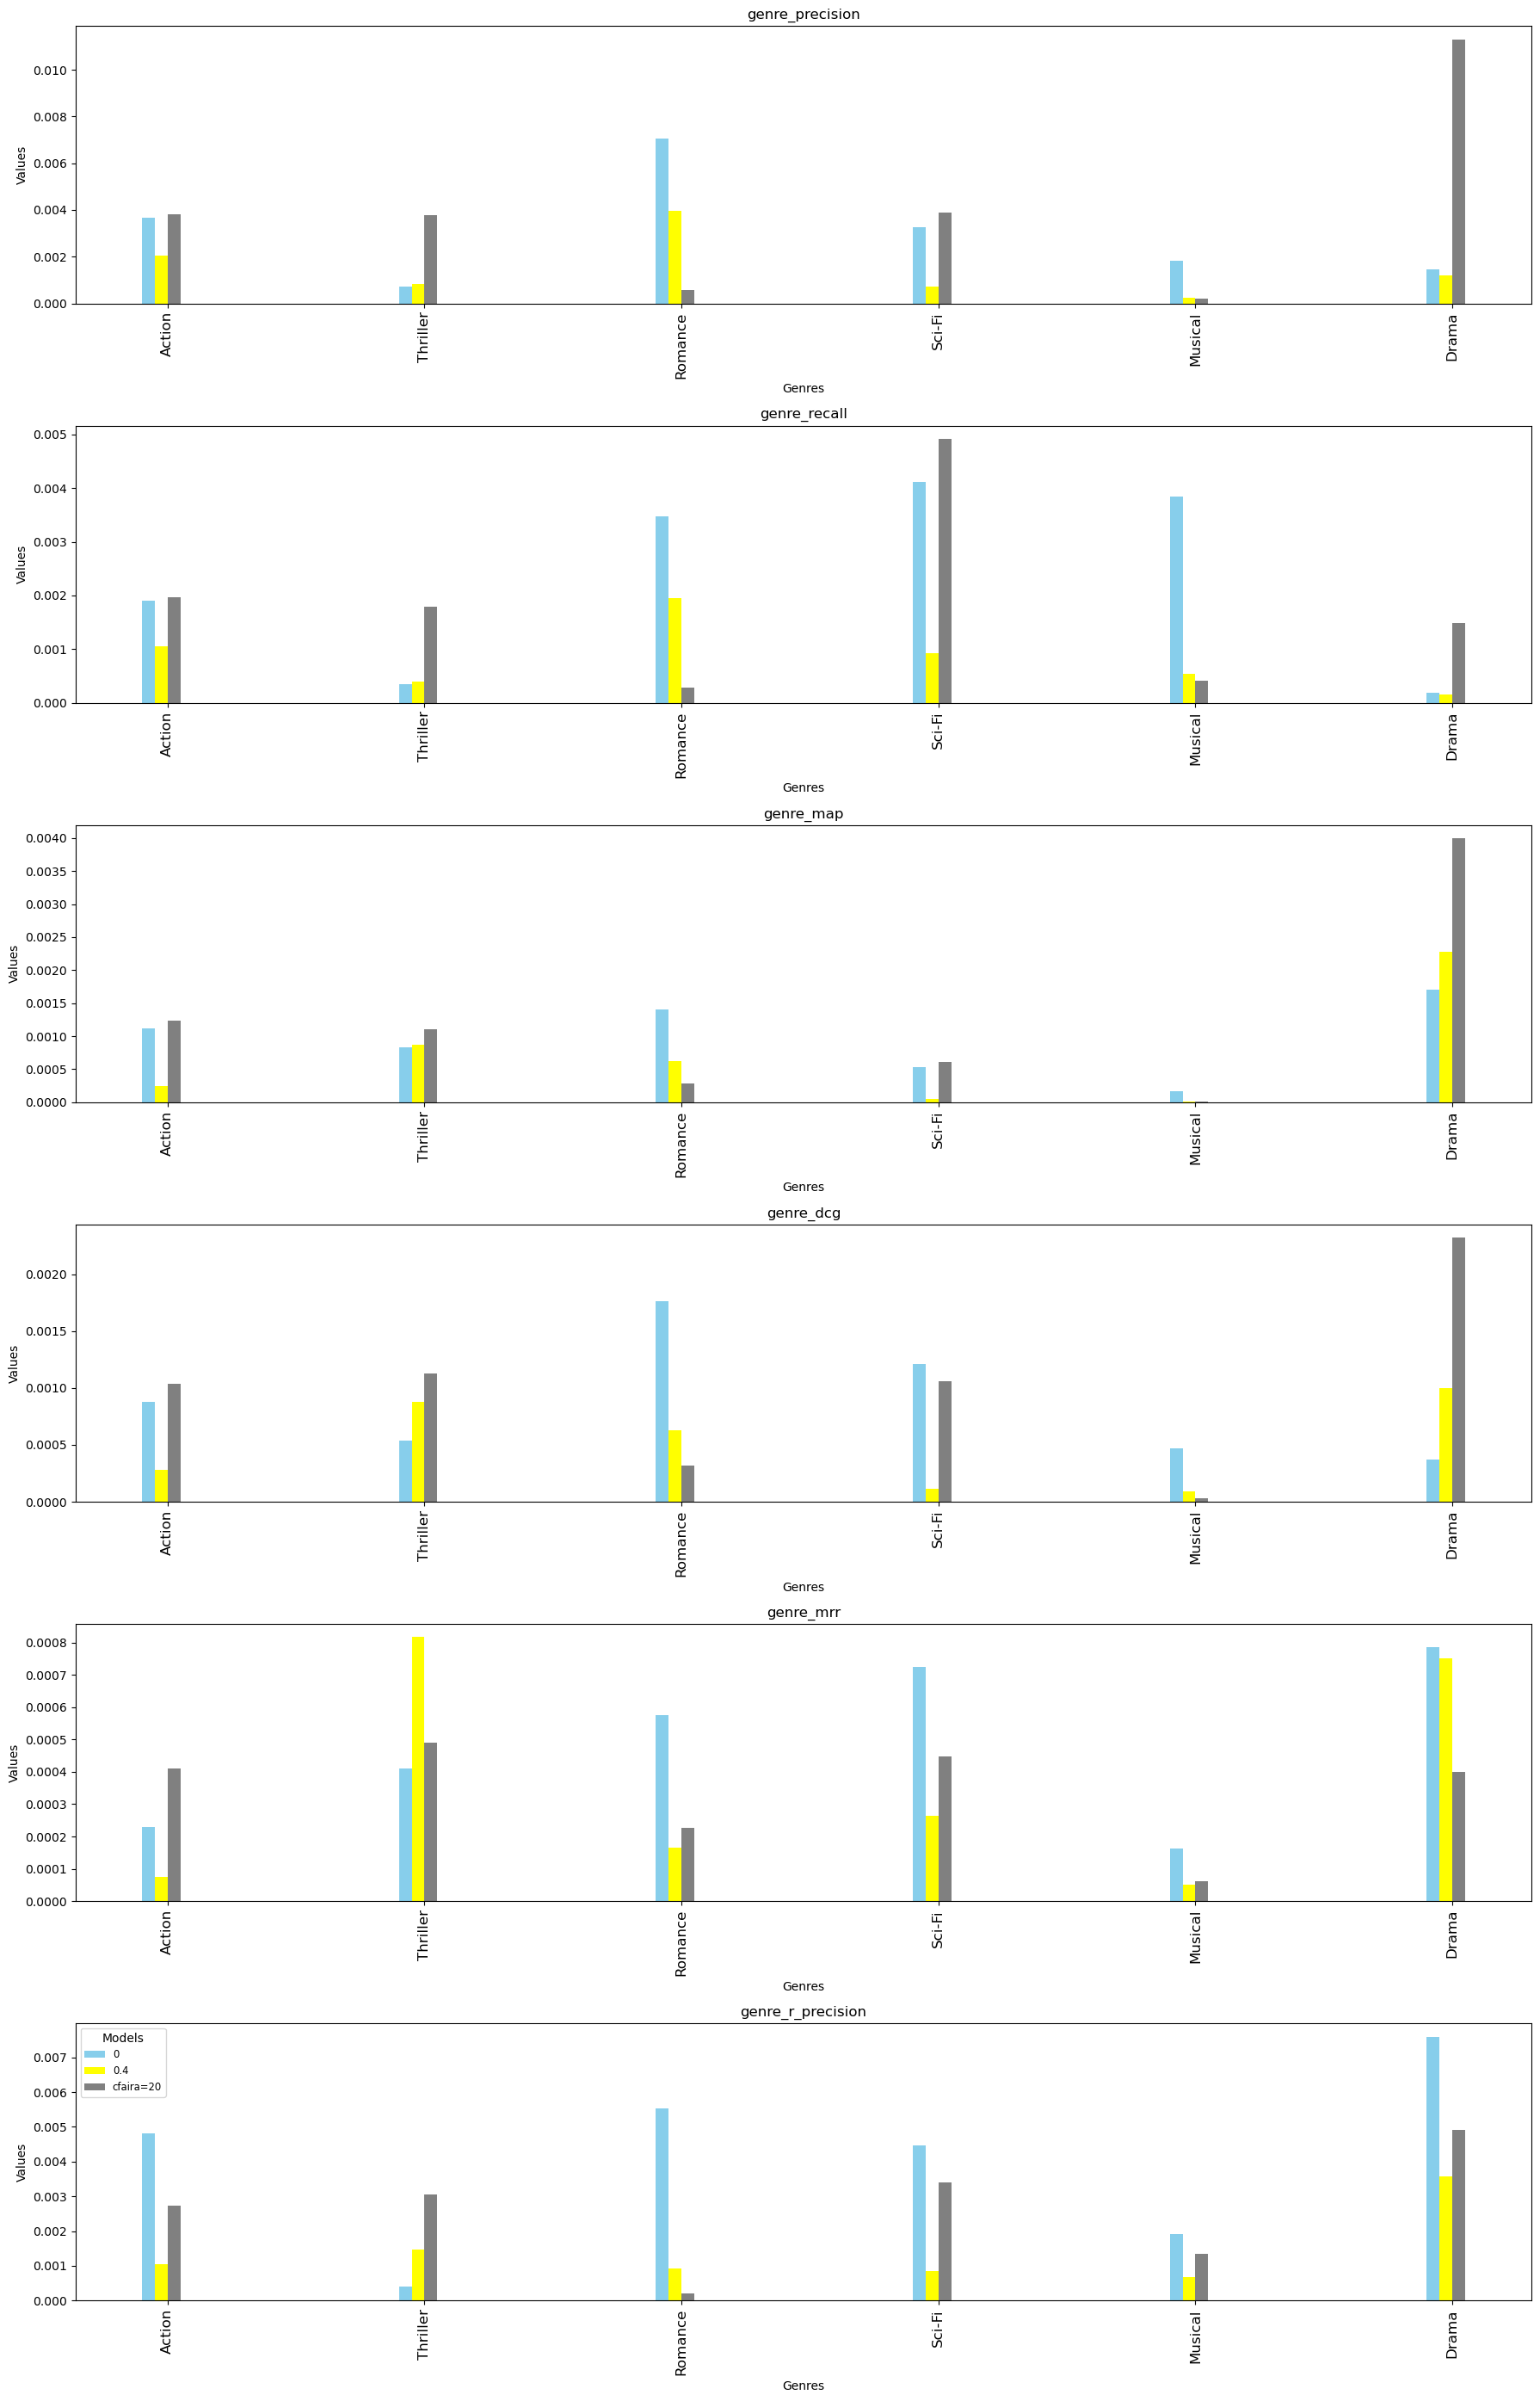

In [39]:


import matplotlib.pyplot as plt
import numpy as np


matrices = [
    model_gps[0][indices],
    model_grs[0][indices],
    model_gms[0][indices],
    model_gdcgs[0][indices],
    model_gmrrs[0][indices],
    model_grps[0][indices],
]
matrices_2 = [
    genre_gp[indices],
    genre_gp_gr[indices],
    genre_gp_gm[indices],
    genre_gp_gndcg[indices],
    genre_gp_gmrr[indices],
    genre_grp[indices],
]


# matrices_8 = [
#     model_gps[7][indices],
#     model_grs[7][indices],
#     model_gms[7][indices],
#     model_gdcgs[7][indices],
#     model_gmrrs[7][indices],
#     model_grps[7][indices],
# ]
# matrices_9 = [
#     model_gps[8][indices],
#     model_grs[8][indices],
#     model_gms[8][indices],
#     model_gdcgs[8][indices],
#     model_gmrrs[8][indices],
#     model_grps[8][indices],
# ]
# matrices_10 = [
#     model_gps[9][indices],
#     model_grs[9][indices],
#     model_gms[9][indices],
#     model_gdcgs[9][indices],
#     model_gmrrs[9][indices],
#     model_grps[9][indices],
# ]
# matrices_11 = [
#     model_gps[10][indices],
#     model_grs[10][indices],
#     model_gms[10][indices],
#     model_gdcgs[10][indices],
#     model_gmrrs[10][indices],
#     model_grps[10][indices],
# ]
matrices_12 = [
    cf_gp[indices],
    cf_gr[indices],
    cf_gm[indices],
    cf_gndcg[indices],
    cf_gmrr[indices],
    cf_grp[indices],
]
# matrices_13 = [
#     cf_gp_10[indices],
#     cf_gr_10[indices],
#     cf_gm_10[indices],
#     cf_gndcg_10[indices],
#     cf_gmrr_10[indices],
#     model_grps[10][indices],
# ]
# matrices_13 = [
#     model_gps[12][indices],
#     model_grs[12][indices],
#     model_gms[12][indices],
#     model_gdcgs[12][indices],
#     model_gmrrs[12][indices],
#     model_grps[12][indices],
# ]



# matrices_2 = [
#     model_gp_2,
#     model_gr_2,
#     model_gm_2,
#     model_gdcg_2,
#     model_gmrr_2,
#     model_grp_2,
# ]
# matrices_3 = [
#     model_gp_3,
#     model_gr_3,
#     model_gm_3,
#     model_gdcg_3,
#     model_gmrr_3,
#     model_grp_3,
# ]

# values2 = matrices[1]
labels = compare_genres
# bar_width = 0.20
titles = [
    "genre_precision",
    "genre_recall",
    "genre_map",
    "genre_dcg",
    "genre_mrr",
    "genre_r_precision",
]


fig, axs = plt.subplots(6, 1, figsize=(18, 28))
axs = axs.flatten()
x = np.arange(len(compare_genres))  # the label locations
bar_width = 0.05  # the width of the bars
# rects1 = ax.bar(x - 3*bar_width/2, gender_genre_weights_topk_recom.iloc[0]*100, bar_width, label='Female (Top 50)', color="#bca0dc")


for i in range(len(titles)):
    axs[i].bar(
        x - 3 * bar_width / 2, abs(matrices[i]), bar_width, color="skyblue", label=alpha_values[0]
    )
    # axs[i].bar(
    #     x - 1 * bar_width / 2, abs(matrices_2[i]), bar_width, color="pink",label=alpha_values[1]
    # )
    # axs[i].bar(
    #     x + 1 * bar_width / 2, abs(matrices_3[i]), bar_width, color="green", label=alpha_values[2]
    # )
    # axs[i].bar(
    #     x + 3 * bar_width / 2, abs(matrices_4[i]), bar_width, color="orange", label=alpha_values[3]
    # )
    # axs[i].bar(
    #     x + 5 * bar_width / 2, abs(matrices_5[i]), bar_width, color="red", label=alpha_values[4]
    # )
    axs[i].bar(
        x -1 * bar_width / 2, abs(matrices_2[i]), bar_width, color="yellow", label="0.4"
    )
    # axs[i].bar(
    #     x +1 * bar_width / 2, abs(matrices_7[i]), bar_width, color="purple", label=alpha_values[6]
    # )
    # axs[i].bar(
    #     x + 11 * bar_width / 2, matrices_8[i], bar_width, color="violet", label=alpha_values[7]
    # )
    # axs[i].bar(
    #     x + 13 * bar_width / 2, matrices_9[i], bar_width, color="black", label=alpha_values[8]
    # )
    # axs[i].bar(
    #     x + 15 * bar_width / 2,
    #     matrices_10[i],
    #     bar_width,
    #     color="chocolate",
    #    label=alpha_values[9]
    # )
    # axs[i].bar(
    #     x + 17 * bar_width / 2, matrices_11[i], bar_width, color="blue", label=alpha_values[10]
    # )
    axs[i].bar(
        x + 1 * bar_width / 2, abs(matrices_12[i]), bar_width, color="gray", label="cfaira=20"
    )
    # axs[i].bar(
    #     x + 21 * bar_width / 2, matrices_13[i], bar_width, color="violet", label="cfaira=10"
    # )
    
    # axs[i].bar(x+2*bar_width/2, matrices_3[i], bar_width,color="green")
    # axs[i].bar(labels, matrices_2[i], color="skyblue")
    axs[i].set_xticks(x)
    axs[i].set_xticklabels(compare_genres, rotation=90, fontsize=12)

    axs[i].set_title(titles[i])
    axs[i].set_xlabel("Genres")
    axs[i].set_ylabel("Values")
    axs[i].tick_params(axis="x", rotation=90)

# plt.legend(loc='upper left', fontsize='small', title='Groups')

handles, labels = axs[0].get_legend_handles_labels()
print(labels)
print(handles)
plt.legend(handles, labels, loc="upper left", fontsize="small", title="Models")

# Adjust layout
plt.tight_layout()
plt.savefig("all_res.pdf" , format="pdf")
plt.show()

###################
# a*gender_loss + (1-a)*mseloss
# genderloss * batch_size * 25
###################

In [89]:
model_gms[4]

array([-2.42455866e-04, -8.64881748e-04, -6.22832516e-04,  5.69355090e-05,
       -4.43709682e-05, -2.24483966e-04, -6.23614776e-07,  2.26664878e-04,
        1.89267756e-05, -2.22584307e-03,  5.37568174e-05,  4.40132925e-05,
        9.33687309e-06,  2.22663179e-06, -1.34581549e-05,  1.28076763e-03,
       -7.32990090e-05,  2.28312671e-03])

['plain', 'a=0.5 with genre reg', 'bp reg']
[<BarContainer object of 18 artists>, <BarContainer object of 18 artists>, <BarContainer object of 18 artists>]


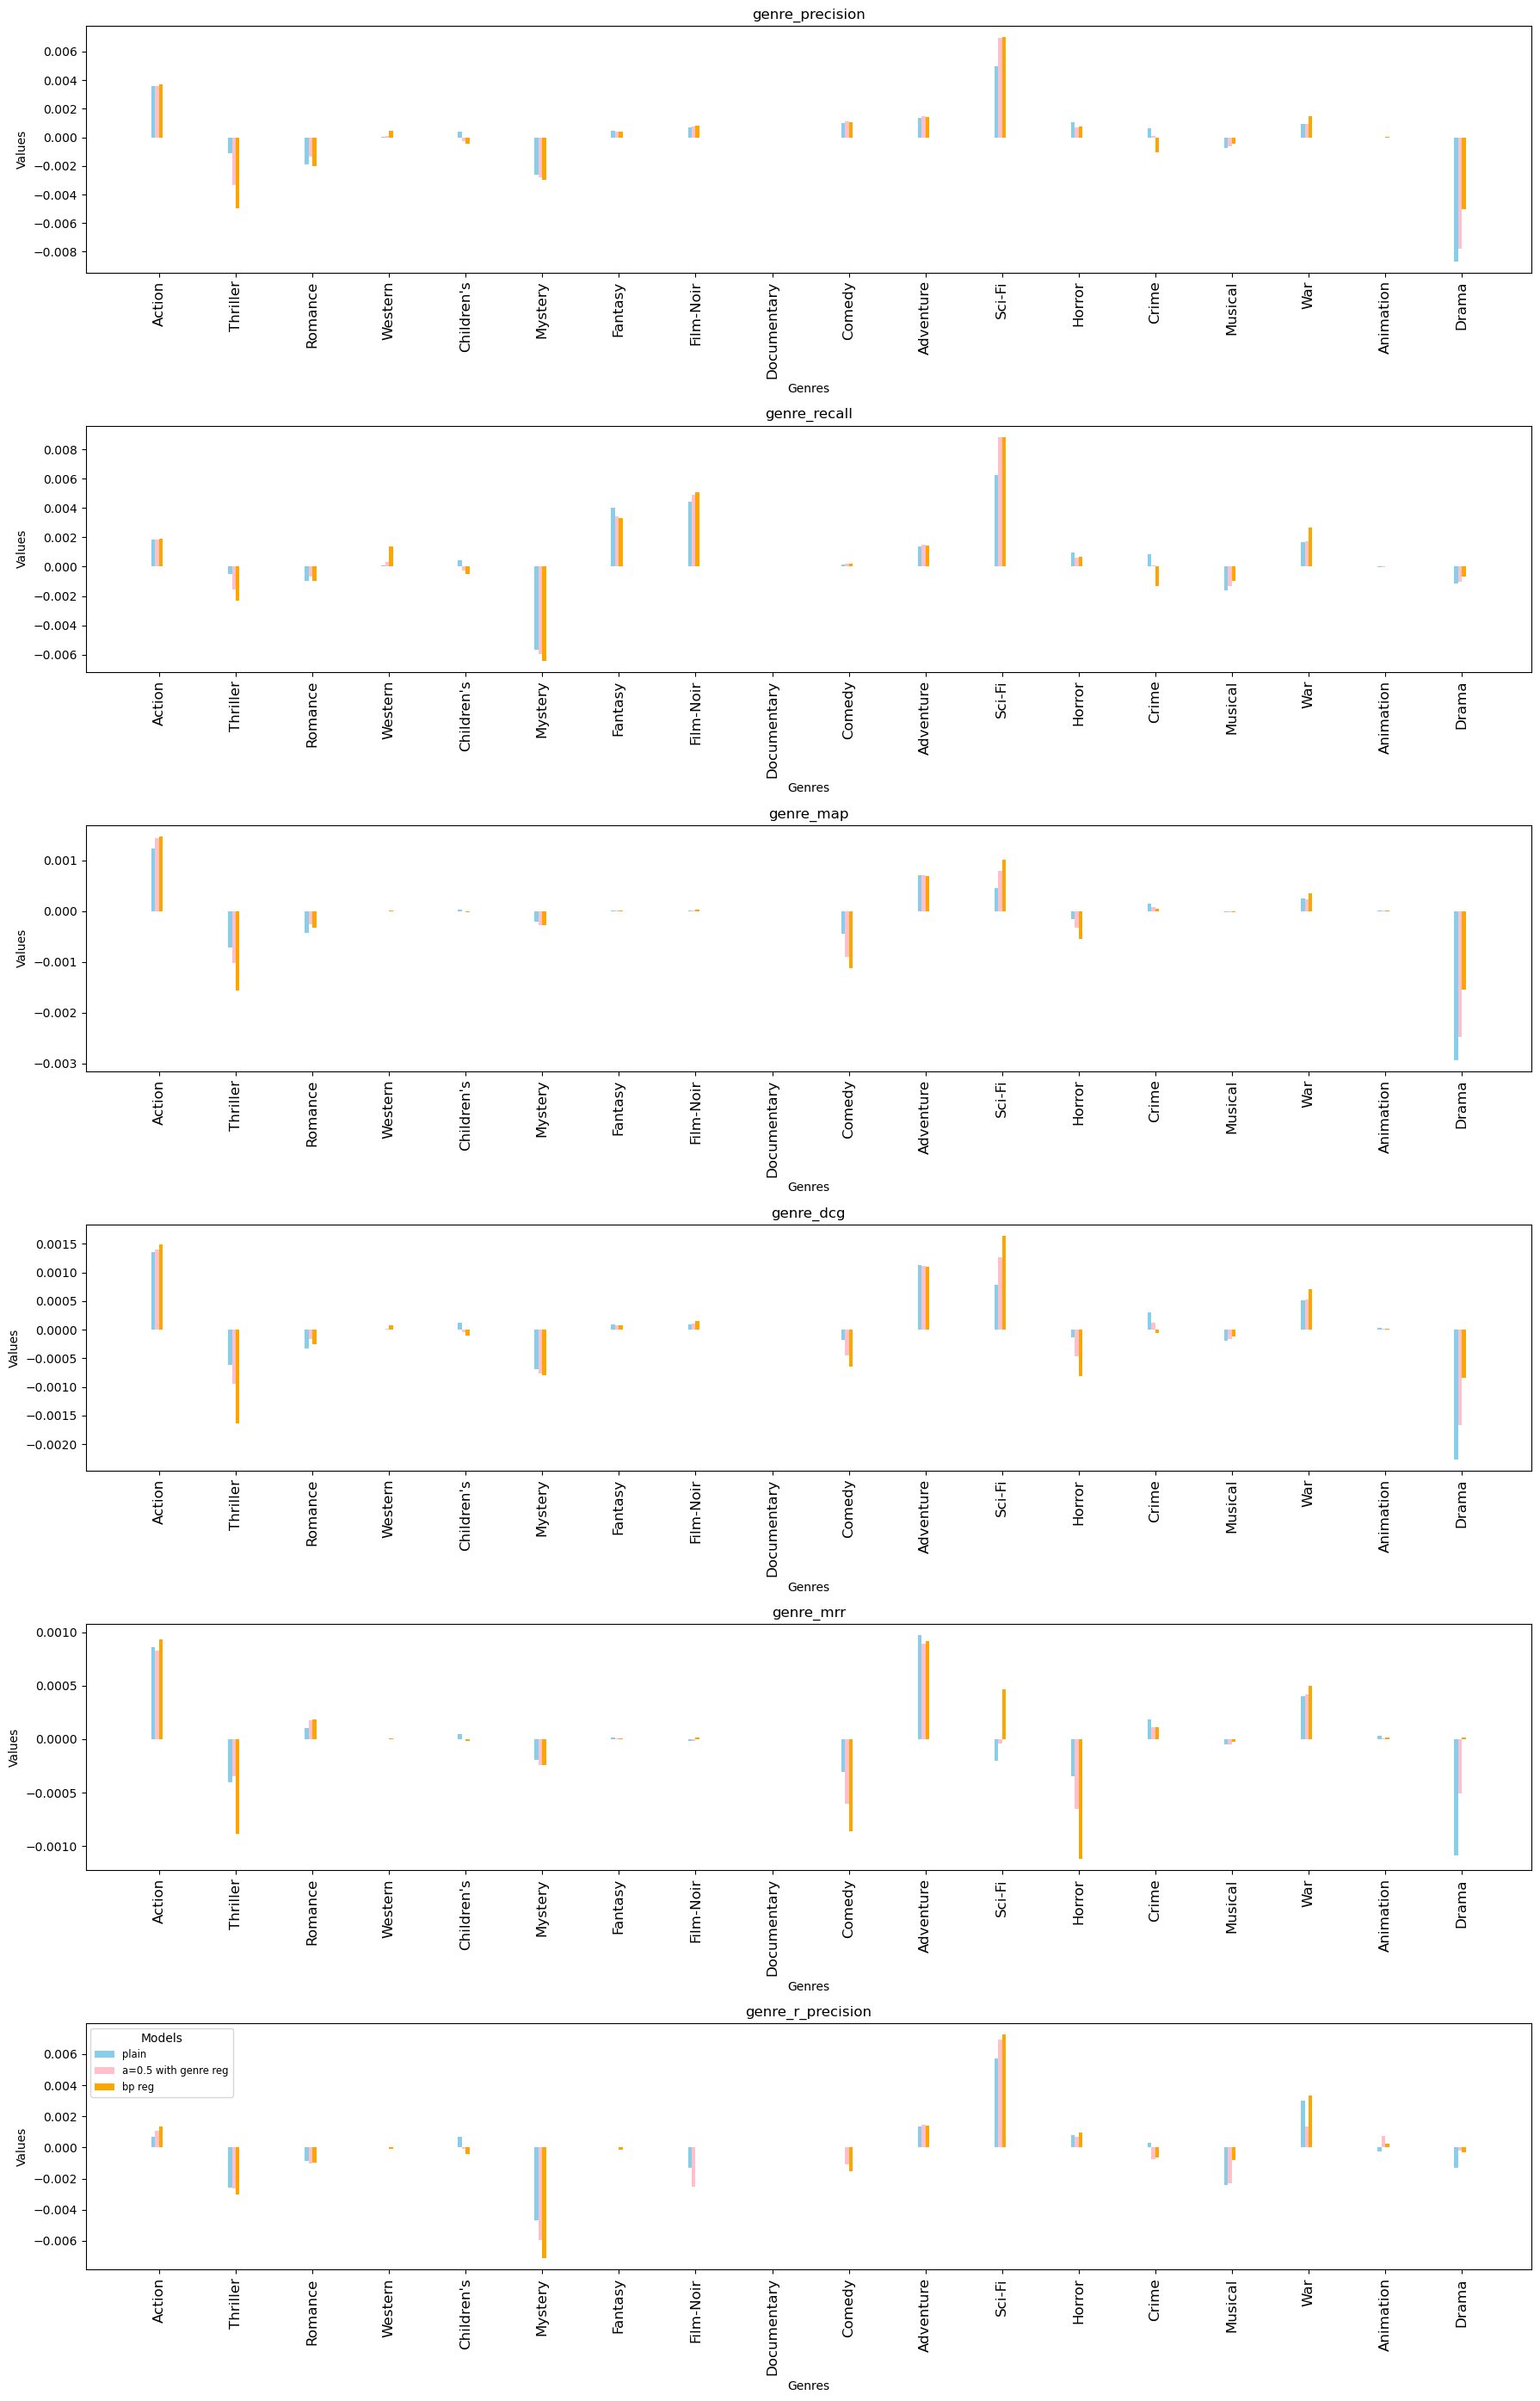

In [29]:
import matplotlib.pyplot as plt
import numpy as np


matrices = [
    model_gps[0][indices],
    model_grs[0][indices],
    model_gms[0][indices],
    model_gdcgs[0][indices],
    model_gmrrs[0][indices],
    model_grps[0][indices],
]
matrices_2 = [
    model_gps[1][indices],
    model_grs[1][indices],
    model_gms[1][indices],
    model_gdcgs[1][indices],
    model_gmrrs[1][indices],
    model_grps[1][indices],
]
matrices_3 = [
    model_gps[2][indices],
    model_grs[2][indices],
    model_gms[2][indices],
    model_gdcgs[2][indices],
    model_gmrrs[2][indices],
    model_grps[2][indices],
]
# matrices_4 = [
#     model_gps[3][indices],
#     model_grs[3][indices],
#     model_gms[3][indices],
#     model_gdcgs[3][indices],
#     model_gmrrs[3][indices],
#     model_grps[3][indices],
# ]
# matrices_5 = [
#     model_gps[4][indices],
#     model_grs[4][indices],
#     model_gms[4][indices],
#     model_gdcgs[4][indices],
#     model_gmrrs[4][indices],
#     model_grps[4][indices],
# ]
# matrices_6 = [
#     model_gps[5][indices],
#     model_grs[5][indices],
#     model_gms[5][indices],
#     model_gdcgs[5][indices],
#     model_gmrrs[5][indices],
#     model_grps[5][indices],
# ]
# matrices_7 = [
#     model_gps[6][indices],
#     model_grs[6][indices],
#     model_gms[6][indices],
#     model_gdcgs[6][indices],
#     model_gmrrs[6][indices],
#     model_grps[6][indices],
# ]
# matrices_8 = [
#     model_gps[7][indices],
#     model_grs[7][indices],
#     model_gms[7][indices],
#     model_gdcgs[7][indices],
#     model_gmrrs[7][indices],
#     model_grps[7][indices],
# ]
# matrices_9 = [
#     model_gps[8][indices],
#     model_grs[8][indices],
#     model_gms[8][indices],
#     model_gdcgs[8][indices],
#     model_gmrrs[8][indices],
#     model_grps[8][indices],
# ]
# matrices_10 = [
#     model_gps[9][indices],
#     model_grs[9][indices],
#     model_gms[9][indices],
#     model_gdcgs[9][indices],
#     model_gmrrs[9][indices],
#     model_grps[9][indices],
# ]
# matrices_11 = [
#     model_gps[10][indices],
#     model_grs[10][indices],
#     model_gms[10][indices],
#     model_gdcgs[10][indices],
#     model_gmrrs[10][indices],
#     model_grps[10][indices],
# ]
# matrices_12 = [
#     model_gps[11][indices],
#     model_grs[11][indices],
#     model_gms[11][indices],
#     model_gdcgs[11][indices],
#     model_gmrrs[11][indices],
#     model_grps[11][indices],
# ]
# matrices_13 = [
#     model_gps[12][indices],
#     model_grs[12][indices],
#     model_gms[12][indices],
#     model_gdcgs[12][indices],
#     model_gmrrs[12][indices],
#     model_grps[12][indices],
# ]



# matrices_2 = [
#     model_gp_2,
#     model_gr_2,
#     model_gm_2,
#     model_gdcg_2,
#     model_gmrr_2,
#     model_grp_2,
# ]
# matrices_3 = [
#     model_gp_3,
#     model_gr_3,
#     model_gm_3,
#     model_gdcg_3,
#     model_gmrr_3,
#     model_grp_3,
# ]

# values2 = matrices[1]
labels = compare_genres
# bar_width = 0.20
titles = [
    "genre_precision",
    "genre_recall",
    "genre_map",
    "genre_dcg",
    "genre_mrr",
    "genre_r_precision",
]


fig, axs = plt.subplots(6, 1, figsize=(18, 28))
axs = axs.flatten()
x = np.arange(len(compare_genres))  # the label locations
bar_width = 0.05  # the width of the bars
# rects1 = ax.bar(x - 3*bar_width/2, gender_genre_weights_topk_recom.iloc[0]*100, bar_width, label='Female (Top 50)', color="#bca0dc")


for i in range(len(titles)):
    axs[i].bar(
        x - 3 * bar_width / 2, matrices[i], bar_width, color="skyblue", label="plain"
    )
    axs[i].bar(
        x - 1 * bar_width / 2, matrices_2[i], bar_width, color="pink",label="a=0.5 with genre reg"
    )
    axs[i].bar(
        x +1* bar_width / 2, matrices_3[i], bar_width, color="orange",label="bp reg"
    )
    # axs[i].bar(
    #     x + 1 * bar_width / 2, matrices_3[i], bar_width, color="green", label=alpha_values[2]
    # )
    # axs[i].bar(
    #     x + 3 * bar_width / 2, matrices_4[i], bar_width, color="orange", label=alpha_values[3]
    # )
    # axs[i].bar(
    #     x + 5 * bar_width / 2, matrices_5[i], bar_width, color="red", label=alpha_values[4]
    # )
    # axs[i].bar(
    #     x + 7 * bar_width / 2, matrices_6[i], bar_width, color="yellow", label=alpha_values[5]
    # )
    # axs[i].bar(
    #     x + 9 * bar_width / 2, matrices_7[i], bar_width, color="purple", label=alpha_values[6]
    # )
    # axs[i].bar(
    #     x + 11 * bar_width / 2, matrices_8[i], bar_width, color="violet", label=alpha_values[7]
    # )
    # axs[i].bar(
    #     x + 13 * bar_width / 2, matrices_9[i], bar_width, color="black", label=alpha_values[8]
    # )
    # axs[i].bar(
    #     x + 15 * bar_width / 2,
    #     matrices_10[i],
    #     bar_width,
    #     color="chocolate",
    #    label=alpha_values[9]
    # )
    # axs[i].bar(
    #     x + 17 * bar_width / 2, matrices_11[i], bar_width, color="blue", label=alpha_values[10]
    # )
    # axs[i].bar(
    #     x + 19 * bar_width / 2, matrices_12[i], bar_width, color="blue", label=alpha_values[11]
    # )
    # axs[i].bar(
    #     x + 21 * bar_width / 2, matrices_13[i], bar_width, color="blue", label=alpha_values[12]
    # )
    
    # axs[i].bar(x+2*bar_width/2, matrices_3[i], bar_width,color="green")
    # axs[i].bar(labels, matrices_2[i], color="skyblue")
    axs[i].set_xticks(x)
    axs[i].set_xticklabels(compare_genres, rotation=90, fontsize=12)

    axs[i].set_title(titles[i])
    axs[i].set_xlabel("Genres")
    axs[i].set_ylabel("Values")
    axs[i].tick_params(axis="x", rotation=90)

# plt.legend(loc='upper left', fontsize='small', title='Groups')

handles, labels = axs[0].get_legend_handles_labels()
print(labels)
print(handles)
plt.legend(handles, labels, loc="upper left", fontsize="small", title="Models")

# Adjust layout
plt.tight_layout()
plt.show()

In [34]:
x= sum(abs(cf_gndcg))
x>gdcg_sum
# gp_sum

array([False, False, False,  True,  True,  True,  True])

In [41]:


all_values = [
    ["a=0 mf", 1.0028, 0.5636, 0.0528, 0.6501, 0.0440, 0.1571, 0.0792, 0.0429, 0.1009, 5.9468, 0.6271],
    ["a=0.1 mf", 1.0007, 0.5609, 0.0529, 0.6575, 0.0432, 0.1519, 0.0784, 0.0430, 0.1015, 133.6435, 0.5747],
    ["a=0.2 mf", 0.9963, 0.5596, 0.0530, 0.6554, 0.0435, 0.1534, 0.0789, 0.0431, 0.1014, 131.6855, 0.5737],
    ["a=0.3 mf", 0.9901, 0.5582, 0.0525, 0.6490, 0.0444, 0.1633, 0.0800, 0.0427, 0.1005, 130.1983, 0.5649],
    ["a=0.4 mf", 0.9860, 0.5556, 0.0542, 0.6511, 0.0453, 0.1734, 0.0831, 0.0439, 0.1035, 134.0786, 0.5741],
    ["a=0.5 mf", 0.9841, 0.5531, 0.0542, 0.6394, 0.0452, 0.1683, 0.0825, 0.0440, 0.1036, 148.7229, 0.6262],
    ["a=0.6 mf", 0.9833, 0.5479, 0.0543, 0.6246, 0.0452, 0.1659, 0.0819, 0.0441, 0.1028, 135.8487, 0.5760],
    ["a=0.7 mf", 0.9855, 0.5381, 0.0522, 0.5938, 0.0442, 0.1574, 0.0781, 0.0426, 0.0972, 137.1758, 0.6263],
    ["a=0.8 mf", 0.9974, 0.5237, 0.0498, 0.5758, 0.0424, 0.1607, 0.0747, 0.0407, 0.0923, 135.4480, 0.7201],
    ["a=0.9 mf", 1.0251, 0.4892, 0.0442, 0.5366, 0.0366, 0.1237, 0.0632, 0.0359, 0.0820, 148.9166, 0.6618],
    ["a=1 mf", 1.1464, 0.3459, 0.0118, 0.3033, 0.0159, 0.0428, 0.0150, 0.0106, 0.0179, 126.6729, 0.7206]
]

# RMSE: [1.004, 1.0018, 0.9973, 0.9908, 0.9868, 0.9836, 0.9837, 0.9849, 0.9962, 1.0251, 1.1211]
# AUC: [0.5636, 0.5612, 0.5597, 0.5589, 0.5558, 0.5538, 0.5482, 0.5394, 0.5255, 0.4904, 0.3283]
# F1@50: [0.0529, 0.0527, 0.053, 0.053, 0.0533, 0.0544, 0.0544, 0.0521, 0.0497, 0.0443, 0.0147]
HitRatios= [0.6532, 0.6522, 0.6596, 0.6564, 0.649, 0.6479, 0.6331, 0.6002, 0.5695, 0.5408, 0.3637]
# MAP: [0.0439, 0.0432, 0.0437, 0.0443, 0.045, 0.0458, 0.0451, 0.0441, 0.0423, 0.0369, 0.0212]
# MRR: [0.1558, 0.1511, 0.1547, 0.1607, 0.1727, 0.1734, 0.1617, 0.1579, 0.1571, 0.1254, 0.1018]
NDCG =  [0.0793, 0.0781, 0.0791, 0.0802, 0.0821, 0.0837, 0.0819, 0.0778, 0.0741, 0.0635, 0.0251]
# Precision@50: [0.043, 0.0429, 0.0431, 0.043, 0.0433, 0.0441, 0.0441, 0.0425, 0.0405, 0.0361, 0.0134]
# Recall@50: [0.1015, 0.1012, 0.1017, 0.1017, 0.1022, 0.1043, 0.1034, 0.0972, 0.0923, 0.082, 0.022


rmse_values_extracted = [values[0] for values in all_values]
auc_values_extracted = [values[1] for values in all_values]
recall_values_extracted = [values[7] for values in all_values]
hit_ratio_values_extracted = [values[4] for values in all_values]


In [ ]:
rmse_values_extracted

[0.9496,
 0.9487,
 0.9481,
 0.9476,
 0.9477,
 0.9488,
 0.9516,
 0.9573,
 0.968,
 0.99,
 1.129]

In [37]:
gp_sum = [sum(abs(model_gps[i])) for i in range(len(models))]
gr_sum = [sum(abs(model_grs[i])) for i in range(len(models))]
gm_sum = [sum(abs(model_gms[i])) for i in range(len(models))]
gdcg_sum = [sum(abs(model_gdcgs[i])) for i in range(len(models))]
gmrr_sum = [sum(abs(model_gmrrs[i])) for i in range(len(models))]
grp_sum = [sum(abs(model_grps[i])) for i in range(len(models))]


In [33]:
gp_sum

[0.05518040201920801,
 0.044788832394802594,
 0.05297452663422812,
 0.039491141362783144,
 0.031629511781750566,
 0.024930242560093324,
 0.025912853315838418]

In [42]:
print(gr_sum)

[0.08625216208453546, 0.06499507628028661, 0.061233304140295125, 0.05615343314003515, 0.052069219811297605, 0.03806050681890036, 0.02732086490625849]


In [65]:
x =sum(abs(cf_gndcg))
print(x>gdcg_sum)
x =sum(abs(cf_gmrr))
print(x>gmrr_sum)
x =sum(abs(cf_gp))
print(x>gp_sum)
x =sum(abs(cf_gr))
print(x>gr_sum)



[False False False False  True  True  True]
[False False False False False False False]
[False False False False  True  True  True]
[False False False False False  True  True]


In [44]:
alpha_values

[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

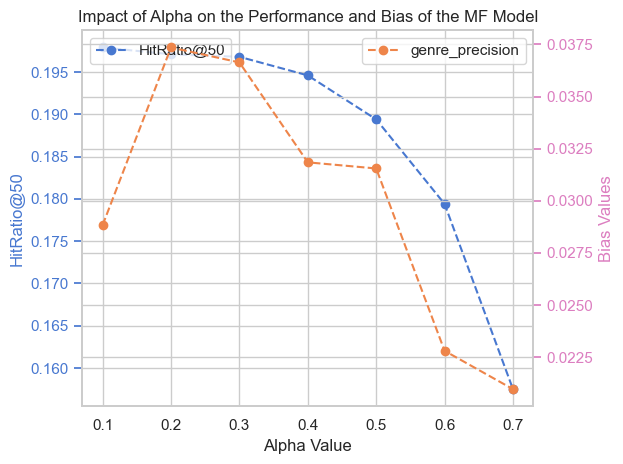

In [45]:

import matplotlib.pyplot as plt
import seaborn as sns


alpha_values=[0,0.1,0.2, 0.3, 0.4, 0.5, 0.6 ]
upper_bound = len(alpha_values)

sns.set(style="whitegrid")
pastel_palette = sns.color_palette("muted")

fig, ax1 = plt.subplots()
# hit_ratio = [0.9067,0.9003,0.8993,0.9003,0.8971,0.8897,0.8791,0.8484,0.7922,0.6744,0.6628]
h = [0.6469, 0.6045, 0.5726, 0.5461, 0.509, 0.4889, 0.4751]
n=[0.1979, 0.1971, 0.1968, 0.1946, 0.1894, 0.1794, 0.1575]

titles = [
    "genre_precision",
    "genre_recall",
    "genre_map",
    "genre_dcg",
    "genre_mrr",
    "genre_r_precision",
]

ax1.plot(x[0:upper_bound], n[0:upper_bound], linestyle="--", marker = "o",color=pastel_palette[0], label="HitRatio@50")
# ax1.plot(x[0:upper_bound], auc_values_extracted[0:upper_bound], linestyle="dotted", color=pastel_palette[0], label="RMSE")
ax1.set_xlabel("Alpha Value")
ax1.set_ylabel("HitRatio@50", color=pastel_palette[0])
ax1.tick_params(axis="y", colors=pastel_palette[0])
ax2 = ax1.twinx()
ax2.plot(x[0:upper_bound], gp_sum[0:upper_bound], label=titles[0], color=pastel_palette[1],linestyle="--", marker = "o")
# ax2.plot(x[0:upper_bound], gr_sum[0:upper_bound], label=titles[1], color=pastel_palette[2])
# ax2.plot(x[0:upper_bound], gm_sum[0:upper_bound], label=titles[2], color=pastel_palette[3])
# ax2.plot(x[0:upper_bound], gdcg_sum[0:upper_bound], label=titles[3], color=pastel_palette[4])
# ax2.plot(x[0:upper_bound], gmrr_sum[0:upper_bound], label=titles[4], color=pastel_palette[5])
# ax2.plot(x[0:upper_bound], grp_sum[0:upper_bound], label=titles[5], color=pastel_palette[6])
ax2.set_ylabel("Bias Values", color=pastel_palette[6])
ax2.tick_params(axis="y", colors=pastel_palette[6])
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.title("Impact of Alpha on the Performance and Bias of the MF Model")
plt.tight_layout()
plt.show()

#  models.append(
#         MF(
#             k=20,
#             seed=123,
#             name=f"a={alpha_values[i]} mf",
#             backend="pytorch",
#             verbose=True,
#             optimizer="adam",batch_size=128,
#             alpha=alpha_values[i],
#             learning_rate=0.001,
#             top_k=50, max_iter=10,
#             # early_stopping=True
#         )
#     )

 # models.append(
    #     MF(
    #         k=20,
    #         seed=123,
    #         name=f"a={alpha_values[i]} mf",
    #         backend="pytorch",
    #         verbose=True,
    #         optimizer="adam",batch_size=400,
    #         alpha=alpha_values[i],
    #         learning_rate=0.001,
    #         top_k=50, max_iter=10,
    #         # early_stopping=True
    #     )
    # )

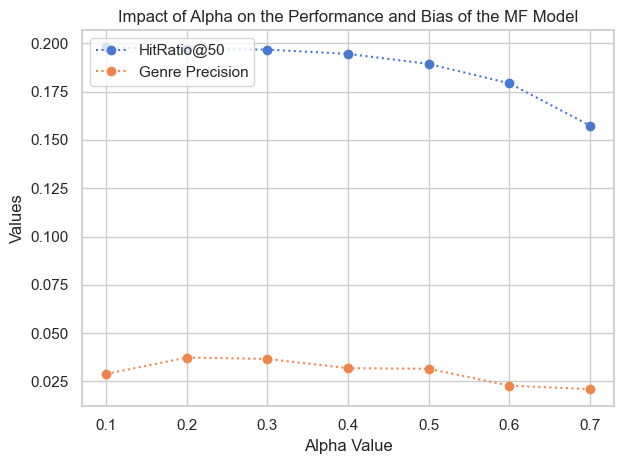

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sample data (replace with your actual data)
# alpha_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
upper_bound = len(alpha_values)
n=[0.1979, 0.1971, 0.1968, 0.1946, 0.1894, 0.1794, 0.1575]

# Set up Seaborn style and colors
sns.set(style="whitegrid")
pastel_palette = sns.color_palette("muted")

# Create the plot
fig, ax1 = plt.subplots()

# Plot both series on the same axis with circular markers and dotted lines
ax1.plot(alpha_values[0:upper_bound], n[0:upper_bound], linestyle=":", marker="o",
         color=pastel_palette[0], label="HitRatio@50")

ax1.plot(alpha_values[0:upper_bound], gp_sum[0:upper_bound], linestyle=":", marker="o",
         color=pastel_palette[1], label="Genre Precision")

# Set labels, title, and legend
ax1.set_xlabel("Alpha Value")
ax1.set_ylabel("Values")
ax1.set_title("Impact of Alpha on the Performance and Bias of the MF Model")
ax1.legend(loc="upper left")

plt.tight_layout()
plt.show()


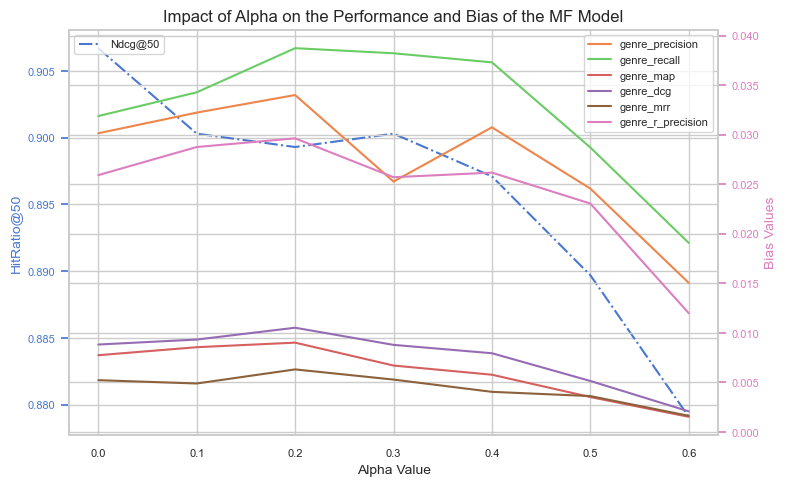

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

x = alpha_values
upper_bound = 

# Set seaborn style and define a pastel color palette
sns.set(style="whitegrid")
pastel_palette = sns.color_palette("muted")

# Create a figure and a set of subplots
fig, ax1 = plt.subplots(figsize=(8, 5))  # Adjust figure size to make it more compact
hit_ratio = [0.9067,0.9003,0.8993,0.9003,0.8971,0.8897,0.8791,0.8484,0.7922,0.6744,0.6628]

# Plot the HitRatio@50
# ax1.plot(x[0:upper_bound], HitRatios[0:upper_bound], linestyle="--", color=pastel_palette[0], label="HitRatio@50")
ax1.plot(x[0:upper_bound], hit_ratio[0:upper_bound], linestyle="-.", color=pastel_palette[0], label="Ndcg@50")
ax1.set_xlabel("Alpha Value", fontsize=10)
ax1.set_ylabel("HitRatio@50", color=pastel_palette[0], fontsize=10)
ax1.tick_params(axis="y", colors=pastel_palette[0], labelsize=8)
ax1.tick_params(axis="x", labelsize=8)

# Create a secondary y-axis for bias values
ax2 = ax1.twinx()
ax2.plot(x[0:upper_bound], gp_sum[0:upper_bound], label=titles[0], color=pastel_palette[1])
ax2.plot(x[0:upper_bound], gr_sum[0:upper_bound], label=titles[1], color=pastel_palette[2])
ax2.plot(x[0:upper_bound], gm_sum[0:upper_bound], label=titles[2], color=pastel_palette[3])
ax2.plot(x[0:upper_bound], gdcg_sum[0:upper_bound], label=titles[3], color=pastel_palette[4])
ax2.plot(x[0:upper_bound], gmrr_sum[0:upper_bound], label=titles[4], color=pastel_palette[5])
ax2.plot(x[0:upper_bound], grp_sum[0:upper_bound], label=titles[5], color=pastel_palette[6])
ax2.set_ylabel("Bias Values", color=pastel_palette[6], fontsize=10)
ax2.tick_params(axis="y", colors=pastel_palette[6], labelsize=8)

# Adjust the legend font size and position to make it smaller and compact
ax1.legend(loc="upper left", fontsize=8)
ax2.legend(loc="upper right", fontsize=8)

# Set the title and adjust layout for compactness
plt.title("Impact of Alpha on the Performance and Bias of the MF Model", fontsize=12)
plt.tight_layout(pad=1)  # Reduce padding around the plot
plt.savefig("100kmf.pdf", format="pdf")
plt.show()
# models.append(
    #     MF(
    #         k=20,
    #         seed=123,
    #         name=f"a={alpha_values[i]} mf",
    #         backend="pytorch",
    #         verbose=True,
    #         optimizer="adam",batch_size=400,
    #         alpha=alpha_values[i],
    #         learning_rate=0.001,
    #         top_k=50, max_iter=10,
    #         # early_stopping=True
    #     )
    # )


In [42]:
sum(abs(cf_gp))> gp_sum

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True])

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


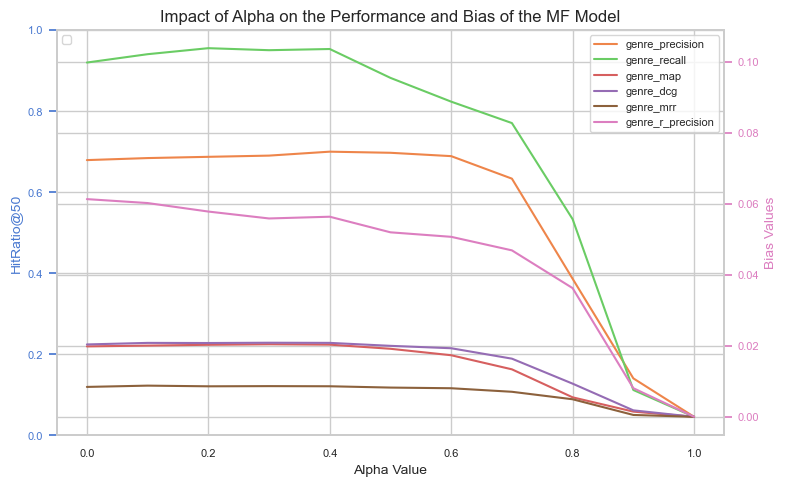

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

x = alpha_values
upper_bound = len(alpha_values)

# Set seaborn style and define a pastel color palette
sns.set(style="whitegrid")
pastel_palette = sns.color_palette("muted")

# Create a figure and a set of subplots
fig, ax1 = plt.subplots(figsize=(8, 5))  # Adjust figure size to make it more compact

# Plot the HitRatio@50
# ax1.plot(x[0:upper_bound], HitRatios[0:upper_bound], linestyle="--", color=pastel_palette[0], label="HitRatio@50")
# ax1.plot(x[0:upper_bound], NDCG[0:upper_bound], linestyle="-.", color=pastel_palette[0], label="Ndcg@50")
ax1.set_xlabel("Alpha Value", fontsize=10)
ax1.set_ylabel("HitRatio@50", color=pastel_palette[0], fontsize=10)
ax1.tick_params(axis="y", colors=pastel_palette[0], labelsize=8)
ax1.tick_params(axis="x", labelsize=8)

# Create a secondary y-axis for bias values
ax2 = ax1.twinx()
ax2.plot(x[0:upper_bound], gp_sum[0:upper_bound], label=titles[0], color=pastel_palette[1])
ax2.plot(x[0:upper_bound], gr_sum[0:upper_bound], label=titles[1], color=pastel_palette[2])
ax2.plot(x[0:upper_bound], gm_sum[0:upper_bound], label=titles[2], color=pastel_palette[3])
ax2.plot(x[0:upper_bound], gdcg_sum[0:upper_bound], label=titles[3], color=pastel_palette[4])
ax2.plot(x[0:upper_bound], gmrr_sum[0:upper_bound], label=titles[4], color=pastel_palette[5])
ax2.plot(x[0:upper_bound], grp_sum[0:upper_bound], label=titles[5], color=pastel_palette[6])
ax2.set_ylabel("Bias Values", color=pastel_palette[6], fontsize=10)
ax2.tick_params(axis="y", colors=pastel_palette[6], labelsize=8)

# Adjust the legend font size and position to make it smaller and compact
ax1.legend(loc="upper left", fontsize=8)
ax2.legend(loc="upper right", fontsize=8)

# Set the title and adjust layout for compactness
plt.title("Impact of Alpha on the Performance and Bias of the MF Model", fontsize=12)
plt.tight_layout(pad=1)  # Reduce padding around the plot
plt.savefig("100kmf.pdf", format="pdf")
plt.show()


In [ ]:
top_k = 20
reco_matrix_n = np.zeros((len(user_ids), top_k), dtype=int)

for i in range(reco_matrix[0].shape[0]):
    reco_matrix_n[i] = reco_matrix[1][i][:top_k]

reco_matrix_n.shape

In [ ]:
reco_matrix[1].shape[0]
# top_k = 50
# reco_matrix = np.zeros((reco_matrix_all_items.shape[0], top_k), dtype=int)
# for i in range(reco_matrix_all_items.shape[0]):
#     reco_matrix[i] = reco_matrix_all_items[i][:top_k]

In [ ]:
sum(model_gdcg_2)

In [ ]:
# np.where(reco_matrix_mapped_items[1][0]==0)
# reco_matrix_all[1][0][258]
reco_matrix_mapped_scores[1][1][1552]

# reco_matrix_mapped_items[1][1][1552]
# reco_matrix_mapped_items[1][0][258]
# reco_items_scores_all[0]
# mapped_item_index

In [ ]:
reco_items_scores_all[0][0]
# np.save("reco_items_scores_all.npy",reco_items_scores_all)

In [ ]:
# unique_genres = ['Crime',
#  'Film-Noir',
#  'Adventure',
#  'Fantasy',
#  'Sci-Fi',
#  'Documentary',
#  'Drama',
#  'Horror',
#  'War',
#  'Animation',
#  'Romance',
#  "Children's",
#  'Western',
#  'Mystery',
#  'Thriller',
#  'Musical',
#  'Action',
#  'Comedy']

In [ ]:
# tahsin kheya
# last modified 21/07/2024
import pandas as pd
import os
import numpy as np
import torch
import time
from logging import getLogger
import random


class Calibration(object):
    def __init__(self, config, movies, top_k, unique_genres, users):
        self.device = "cuda:0" if torch.cuda.is_available() else "cpu"
        self.device = torch.device(self.device)
        # self.logger = getLogger()
        self.reco_distribution = []
        self.kl = []

        # self.logger = getLogger()
        self.top_k = top_k
        self.gkl = []
        self.gender_df = users
        self.actual_genre_dist = pd.read_csv(
            os.path.join(config["user_genre_dist_file"]),
            sep="\t",
        )
        self.unique_genres = list(self.actual_genre_dist.columns)[1:]

        # self.actual_genre_dist = self.actual_genre_dist.drop(columns=["userID"])

        self.config = config
        self.item_df = movies
        self.actual_distribution_without_id = self.actual_genre_dist.drop(
            columns=["userID"]
        ).to_numpy()
        print(self.unique_genres)
        # print(self.actual_distribution_without_id)

        self.actual_distribution_gender = []

    def get_all_user_recommended_genre_dist(self, topk_reco):

        df_reco = pd.DataFrame(
            {
                "userID": np.repeat(np.arange(topk_reco.shape[0]), self.top_k),
                "itemID": topk_reco.flatten(),
                "rank": np.tile(np.arange(1, self.top_k + 1), topk_reco.shape[0]),
            }
        )

        df_reco["weight_factor"] = 1 / (df_reco["rank"]) ** 0.1
        merged_df = pd.merge(df_reco, self.item_df, on="itemID", how="inner")
        merged_df[self.unique_genres] = merged_df[self.unique_genres].div(
            merged_df[self.unique_genres].sum(axis=1), axis=0
        )

        merged_df[self.unique_genres] = (
            merged_df["weight_factor"].values[:, None] * merged_df[self.unique_genres]
        )
        reco_distribution = merged_df[["userID"] + self.unique_genres]
        reco_distribution = reco_distribution.groupby("userID")[
            self.unique_genres
        ].mean()
        #         reco_distribution[self.unique_genres] = reco_distribution[
        #             self.unique_genres
        #         ].div(reco_distribution[self.unique_genres].sum(axis=1), axis=0)

        return reco_distribution

    def get_recom_distribution(self, reco):

        reco = np.array(reco)
        weights = 1 / (np.arange(len(reco)) + 1) ** 0.1
        item_genre_weights = np.zeros((len(reco), len(self.unique_genres)))

        for i, itemID in enumerate(reco):
            item_index = self.item_df.index.get_loc(itemID)
            item_genre_weights[i] = (
                weights[i] * self.item_df.loc[item_index, self.unique_genres]
            )
        #         print(item_genre_weights)
        # Normalize genre weights so sum is 1
        #         item_genre_weights /= torch.sum(item_genre_weights, axis=1, keepdims=True)

        return item_genre_weights

    def get_kl_div(self, q_dist, p_dist, a, uid):
        kl_div = 0
        qg_u = (1 - a) * q_dist + a * p_dist
        nonzero_indices = np.where(p_dist != 0)

        kl_div = np.sum(
            p_dist[nonzero_indices]
            * np.log10(p_dist[nonzero_indices] / qg_u[nonzero_indices])
        )

        return kl_div

    # def get_gender_representation_one_user(self, reco_dist, uid):
    #     c = []
    #     retVal = []
    #     print(self.actual_distribution[uid])

    #     for i in range(len(self.unique_genres)):
    #         c.append(np.log(reco_dist[i] / self.actual_distribution[uid][i + 1]))
    #     # Assuming self.unique_genres is a list or array-like
    #     genre_columns_count = len(self.unique_genres)

    #     reco_dist_slice = reco_dist[:genre_columns_count]
    #     actual_dist_slice = self.actual_distribution[uid][1 : genre_columns_count + 1]

    #     log_ratios = np.log(reco_dist_slice / actual_dist_slice)
    #     retVal.extend(log_ratios.tolist())

    def compute_diversity_score(self, reco_items, uid, l, scores, user_reco, b):

        # -----------------the diversity term----------------------------------
        alpha = 0.01
        # reco_items=self.reco_distribution[uid]
        sum_score = 0
        reco_dist = self.get_recom_distribution(reco_items)
        # print(reco_dist)
        #
        sum_dist = np.sum(reco_dist, axis=0)
        avg_dist = sum_dist / reco_dist.shape[0]
        # 1x18 array (it already is, but let's reshape explicitly)
        reco_dist = avg_dist.reshape(1, -1)
        # normalise values
        reco_dist = reco_dist / sum(reco_dist[0])
        # print(f"reco item {reco_items}, genre_dist_actual_user {self.actual_distribution_without_id[uid]}, reco genre distribution {reco_dist}")
        kl = self.get_kl_div(
            reco_dist[0], self.actual_distribution_without_id[uid], alpha, uid
        )

        # -----------------the diversity term----------------------------------

        # -----------------the fairness term----------------------------------
        # recommended dist mean for each gender
        male_user_ids = self.gender_df[self.gender_df["Gender"] == 0]["userID"]
        male_user_ids = male_user_ids.to_list()
        gender_genre_dist = self.actual_distribution_gender
        # gender_reco_dist = self.get_gender_representation_one_user(reco_dist[0],uid)
        if uid in male_user_ids:
            compare_dist = gender_genre_dist.to_numpy()[1]
        else:
            compare_dist = gender_genre_dist.to_numpy()[0]

        # gender_kl = self.get_kl_div(reco_dist[0], compare_dist, alpha, uid)
        gender_kl = 0

        # -----------------the fairness term----------------------------------

        for r in range(len(reco_items)):
            sum_score += scores[reco_items[r]]

        # print(f"genderkl {gender_kl}, kl {kl} score{sum_score}")

        # if len(reco_items) == 5:
        #     self.kl.append(kl)
        #     self.gkl.append(gender_kl)
        #     print(":;;;;;;;;;;;")
        #     print(uid)

        #     print(self.kl)
        #     print(self.gkl)
        #     print(":;;;;;;;;;;;")
        # print(f"score {sum_score}, kl {kl}, gender_kl {gender_kl}")

        return (1 - l - b) * sum_score - l * kl - b * gender_kl

    # c.get_improved_reco(reco_matrix,reco_matrix_all_items,reco_matrix_all_scores, users)

    def get_improved_reco(self, top_items, items, scores):

        # reco = torch.cat(batch_matrix_list, dim=0).cpu().numpy()

        # scores = torch.cat(batch_score_list, dim=0).cpu().numpy()
        # self.reco_distribution = self.get_recom_distribution(reco)
        return self.get_new_recommendations(
            reco=top_items, scores=scores, all_items=items
        )

    def get_kl_div_gender(self, female_dist, male_dist, a):
        kl_div = 0
        for i in range(len(self.unique_genres)):
            female_dist = (1 - a) * female_dist[i] + a * male_dist[i]
            if male_dist[i] == 0:
                continue
            kl_div = kl_div + male_dist[i] * np.log10(male_dist[i] / female_dist[i])

        return kl_div

    def get_gender_genre_dist(self, user_reco):
        # gender_df = pd.DataFrame(self.genders.items(), columns=["userID", "gender"])
        actual_dist_gender = pd.merge(
            self.actual_genre_dist, self.gender_df, on="userID"
        )
        recomen_df = pd.merge(user_reco, self.gender_df, on="userID")
        # gender_genre_weights_r = recomen_df.groupby("gender")[
        #     self.unique_genres
        # ].mean()
        gender_genre_weights_a = actual_dist_gender.groupby("Gender")[
            self.unique_genres
        ].mean()
        self.actual_distribution_gender = gender_genre_weights_a.sort_index()

    def get_new_recommendations(self, reco, scores, all_items):
        """reco is 6040x50 and scores is 6040x3416"""

        user_reco_dist = self.get_all_user_recommended_genre_dist(reco)
        self.get_gender_genre_dist(user_reco_dist)

        #####
        # gender_discriminated_agaisnt = self.get_gender_discriminated_agaisnt(
        #     user_reco_dist
        # )
        # male_user_ids = [user_id for user_id, gender in self.genders.items() if gender == 0]
        # female_user_ids = [user_id for user_id, gender in self.genders.items() if gender == 1]
        # for each gender clculate the skew for each genre:
        b = 0.69  # beta
        l = 0.29  # lambda
        all_users = []

        #####

        top_k = self.top_k

        n_users, n_items = all_items.shape

        for u in range(0, 50):
            # remaining_items = all_items
            remaining_items = list(all_items[u])
            # print(remaining_items)

            #             u_calibrated = [623, 1612, 558, 1087, 1347, 3368, 196, 3256, 3127, 882, 831, 1271, 1870, 2594, 3279, 2624, 393, 1496, 3099, 2414, 1232, 1773, 1313, 610, 500, 2855, 1973, 1872, 3334, 3296, 649, 769, 1573, 2474, 2133, 2161, 3387, 2640, 1583, 3287, 753, 384, 2192, 709, 1981, 3311 ]
            u_calibrated = []
            for k in range(top_k):
                diversity_scores = [
                    self.compute_diversity_score(
                        u_calibrated + [i], u, l, scores[u], user_reco_dist, b
                    )
                    for i in remaining_items
                ]
                max_index = np.argmax(diversity_scores)

                best_item = remaining_items[max_index]
                u_calibrated.append(best_item)
                remaining_items.pop(max_index)
                print(u_calibrated)
                # self.logger.info(u_calibrated)

            # self.logger.info(u_calibrated)

            all_users.append(u_calibrated)

        return np.array(all_users)

In [ ]:
reco_matrix_all[1].shape

In [ ]:
score_dicts[1][889]
reco_matrix_all[1][0][0]
score_dicts[1][0]

In [ ]:
# from cornac.reranking.Calibration import Calibration
config = {"user_genre_dist_file": "./cornac/data_c/user_genre_dist_new.csv"}
c = Calibration(
    config=config, movies=movies, top_k=50, unique_genres=unique_genres, users=users
)
# for itemknn

reranked_reco = c.get_improved_reco(reco_matrix[1], reco_matrix_all[1], score_dicts)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

matrices = MF_gm


values1 = matrices[0]
values2 = matrices[1]
# values2 = matrices[2]
# values2 = matrices[3]
# values3 = matrices[2]
labels = unique_genres
bar_width = 0.25
titles = ["MF_gp", "MF_gm"]


fig, axs = plt.subplots(2, 3, figsize=(18, 12))
axs = axs.flatten()


for i in range(len(matrices)):
    axs[i].bar(labels, matrices[i], color="skyblue")
    axs[i].set_title(titles[i])
    axs[i].set_xlabel("Genres")
    axs[i].set_ylabel("Values")
    axs[i].tick_params(axis="x", rotation=90)

# Adjust layout
plt.tight_layout()
plt.show()

In [ ]:
print(user_features_numpy[:, 1].shape)

In [ ]:
# Calculate total number of genres
total_genres = len(unique_genres)  # Exclude 'itemID'
# Assuming 'column_name' is the name of the column you want to convert to float
movies[unique_genres] = movies[unique_genres].astype(float)

# Iterate over each row
for index, row in movies.iterrows():
    # Find genres with value 1
    present_genres = [genre for genre in unique_genres if row[genre] == 1]
    num_present_genres = len(present_genres)

    # Calculate weight for each present genre
    if num_present_genres > 0:
        weight_per_genre = 1 / num_present_genres
        for genre in present_genres:
            if movies.at[index, genre] == 1:
                movies.at[index, genre] = weight_per_genre

In [ ]:
# mergde_pd = pd.merge(rating_data_pd,users, how="inner", on="userID")
mergde_pd = pd.merge(rating_data_pd, movies, how="inner", on="itemID")
mergde_pd

In [ ]:
user_genre_means = mergde_pd.groupby("userID")[unique_genres].mean()
user_genre_means

In [ ]:
users

In [ ]:
useer = pd.merge(user_genre_means, users, on="userID", how="inner")
user_genre_gender = useer.groupby("Gender")[unique_genres].mean()
user_genre_gender

In [ ]:
rating_data_pd

In [ ]:
# inter_movies
z = inter_movies[["userID", "itemID", "Gender"]]
mergz = pd.merge(z, movies, on="itemID", how="left")
mergz
user_genre_gender = mergz.groupby("Gender")[unique_genres].mean()
user_genre_gender

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting
x = np.arange(len(unique_genres))  # the label locations
bar_width = 0.1  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))  # Set the figure size

# Plot the data
rects1 = ax.bar(
    x - 3 * bar_width / 2,
    user_genre_gender.iloc[0] * 100,
    bar_width,
    label="male (Top 50)",
    color="#bca0dc",
)
rects2 = ax.bar(
    x + bar_width / 2,
    user_genre_gender.iloc[1] * 100,
    bar_width,
    label="feMale (Top 50)",
    color="#ff3c00",
)

# rects3 = ax.bar(x - 5*bar_width/2, gender_genre_weights_topk_over.iloc[0]*100, bar_width, label='Female (over sampled )',color="#4d9fff")
# rects4 = ax.bar(x + 5*bar_width/2, gender_genre_weights_topk_over.iloc[1]*100, bar_width, label='Male (over sampled )',color="#78eaff")

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel("Genres", fontsize=14)
ax.set_ylabel("% Values", fontsize=14)
ax.set_title("Values by Genre and Gender top 50 vs All Data", fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(unique_genres, rotation=90, fontsize=12)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting
x = np.arange(len(unique_genres))  # the label locations
bar_width = 0.1  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))  # Set the figure size

# Plot the data
rects1 = ax.bar(
    x - 3 * bar_width / 2,
    user_genre_gender.iloc[0] * 100,
    bar_width,
    label="male (Top 50)",
    color="#bca0dc",
)
rects2 = ax.bar(
    x + bar_width / 2,
    user_genre_gender.iloc[1] * 100,
    bar_width,
    label="female (Top 50)",
    color="#ff3c00",
)

# rects3 = ax.bar(x - 5*bar_width/2, gender_genre_weights_topk_over.iloc[0]*100, bar_width, label='Female (over sampled )',color="#4d9fff")
# rects4 = ax.bar(x + 5*bar_width/2, gender_genre_weights_topk_over.iloc[1]*100, bar_width, label='Male (over sampled )',color="#78eaff")

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel("Genres", fontsize=14)
ax.set_ylabel("% Values", fontsize=14)
ax.set_title("Values by Genre and Gender top 50 vs All Data", fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(unique_genres, rotation=90, fontsize=12)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
# inter_movies["itemID"].nunique()
reco_matrix_new.shape

In [ ]:
# Generate userID array
user_ids = np.arange(1, reco_matrix_new.shape[0] + 1).repeat(reco_matrix_new.shape[1])

# Flatten movie_ids array
flat_movie_ids = reco_matrix_new.flatten()

# Create DataFrame
df = pd.DataFrame({"userID": user_ids, "itemID": flat_movie_ids})

mepd = pd.merge(df, movies, on="itemID", how="inner")
mepd = pd.merge(mepd, users, on="userID", how="inner")
user_genre_gender_1 = mepd.groupby("Gender")[unique_genres].mean()

user_genre_gender_1
# Print the DataFrame

In [ ]:
# Generate userID array
user_ids = np.arange(1, reco_matrix[1].shape[0] + 1).repeat(reco_matrix[1].shape[1])

# Flatten movie_ids array
flat_movie_ids = reco_matrix[1].flatten()

# Create DataFrame
df = pd.DataFrame({"userID": user_ids, "itemID": flat_movie_ids})

mepd = pd.merge(df, movies, on="itemID", how="inner")
mepd = pd.merge(mepd, users, on="userID", how="inner")
user_genre_gender_2 = mepd.groupby("Gender")[unique_genres].mean()

user_genre_gender_2
# Print the DataFrame

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting
x = np.arange(len(unique_genres))  # the label locations
bar_width = 0.1  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))  # Set the figure size

# Plot the data
rects1 = ax.bar(
    x - 3 * bar_width / 2,
    user_genre_gender_1.iloc[0] * 100,
    bar_width,
    label="Female (Top 50)",
    color="#bca0dc",
)
rects2 = ax.bar(
    x + bar_width / 2,
    user_genre_gender_1.iloc[1] * 100,
    bar_width,
    label="Male (Top 50)",
    color="#ff3c00",
)

# rects3 = ax.bar(x - 5*bar_width/2, gender_genre_weights_topk_over.iloc[0]*100, bar_width, label='Female (over sampled )',color="#4d9fff")
# rects4 = ax.bar(x + 5*bar_width/2, gender_genre_weights_topk_over.iloc[1]*100, bar_width, label='Male (over sampled )',color="#78eaff")

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel("Genres", fontsize=14)
ax.set_ylabel("% Values", fontsize=14)
ax.set_title("Values by Genre and Gender top 50 vs All Data", fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(unique_genres, rotation=90, fontsize=12)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting
x = np.arange(len(unique_genres))  # the label locations
bar_width = 0.1  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))  # Set the figure size

# Plot the data
rects1 = ax.bar(
    x - 3 * bar_width / 2,
    user_genre_gender_1.iloc[0] * 100,
    bar_width,
    label="Female (Top 50)",
    color="#bca0dc",
)
rects2 = ax.bar(
    x + bar_width / 2,
    user_genre_gender_1.iloc[1] * 100,
    bar_width,
    label="Male (Top 50)",
    color="#ff3c00",
)

# rects3 = ax.bar(x - 5*bar_width/2, gender_genre_weights_topk_over.iloc[0]*100, bar_width, label='Female (over sampled )',color="#4d9fff")
# rects4 = ax.bar(x + 5*bar_width/2, gender_genre_weights_topk_over.iloc[1]*100, bar_width, label='Male (over sampled )',color="#78eaff")

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel("Genres", fontsize=14)
ax.set_ylabel("% Values", fontsize=14)
ax.set_title("Values by Genre and Gender top 50 vs All Data", fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(unique_genres, rotation=90, fontsize=12)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
##use 0 and 0.5 as alpha

In [ ]:
# Generate userID array
user_ids = np.arange(1, reco_matrix[1].shape[0] + 1).repeat(reco_matrix[1].shape[1])

# Flatten movie_ids array
flat_movie_ids = reco_matrix[1].flatten()

# Create DataFrame
df = pd.DataFrame({"userID": user_ids, "itemID": flat_movie_ids})

mepd = pd.merge(df, movies, on="itemID", how="inner")
mepd = pd.merge(mepd, users, on="userID", how="inner")
user_genre_gender_1 = mepd.groupby("Gender")[unique_genres].mean()

user_genre_gender_1
# Print the DataFrame

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting
x = np.arange(len(unique_genres))  # the label locations
bar_width = 0.1  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))  # Set the figure size

# Plot the data
rects1 = ax.bar(
    x - 3 * bar_width / 2,
    user_genre_gender_1.iloc[0] * 100,
    bar_width,
    label="Female (Top 50)",
    color="#bca0dc",
)
rects2 = ax.bar(
    x + bar_width / 2,
    user_genre_gender_1.iloc[1] * 100,
    bar_width,
    label="Male (Top 50)",
    color="#ff3c00",
)

# rects3 = ax.bar(x - 5*bar_width/2, gender_genre_weights_topk_over.iloc[0]*100, bar_width, label='Female (over sampled )',color="#4d9fff")
# rects4 = ax.bar(x + 5*bar_width/2, gender_genre_weights_topk_over.iloc[1]*100, bar_width, label='Male (over sampled )',color="#78eaff")

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel("Genres", fontsize=14)
ax.set_ylabel("% Values", fontsize=14)
ax.set_title("Values by Genre and Gender top 50 vs All Data", fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(unique_genres, rotation=90, fontsize=12)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
inter_movies

In [ ]:
inter_movies.to_csv("biased_movie_lens.csv")

In [ ]:
movies_df

In [ ]:

np.save('reco_matrix.npy', reco_matrix)
np.save('reco_matrix_mapped_items.npy', reco_matrix_mapped_items)
np.save('reco_matrix_mapped_scores.npy', reco_matrix_mapped_scores)
np.save('reco_matrix_all.npy', reco_matrix_all)np.save('reco_items_scores_all.npy' , reco_matrix_all_edited)

#reco_matrix_all_items

In [ ]:
import torch

In [ ]:
x=t[..., 1].sum()

In [ ]:
x

tensor(6.1665)

In [1]:
model_gps[0]

NameError: name 'model_gps' is not defined

In [27]:
import numpy as np

def sigmoid_adjustment(original_value, k):
    return 1 / (1 + np.exp(-k * (original_value - 0.5)))

original_value = 0.042
k = 0.1

transformed_value = sigmoid_adjustment(original_value, k)
print(transformed_value)


0.4885520010784135


['0', '0.6', 'cfaira=10', 'cfaira=10']
[<BarContainer object of 6 artists>, <BarContainer object of 6 artists>, <BarContainer object of 6 artists>, <BarContainer object of 6 artists>]


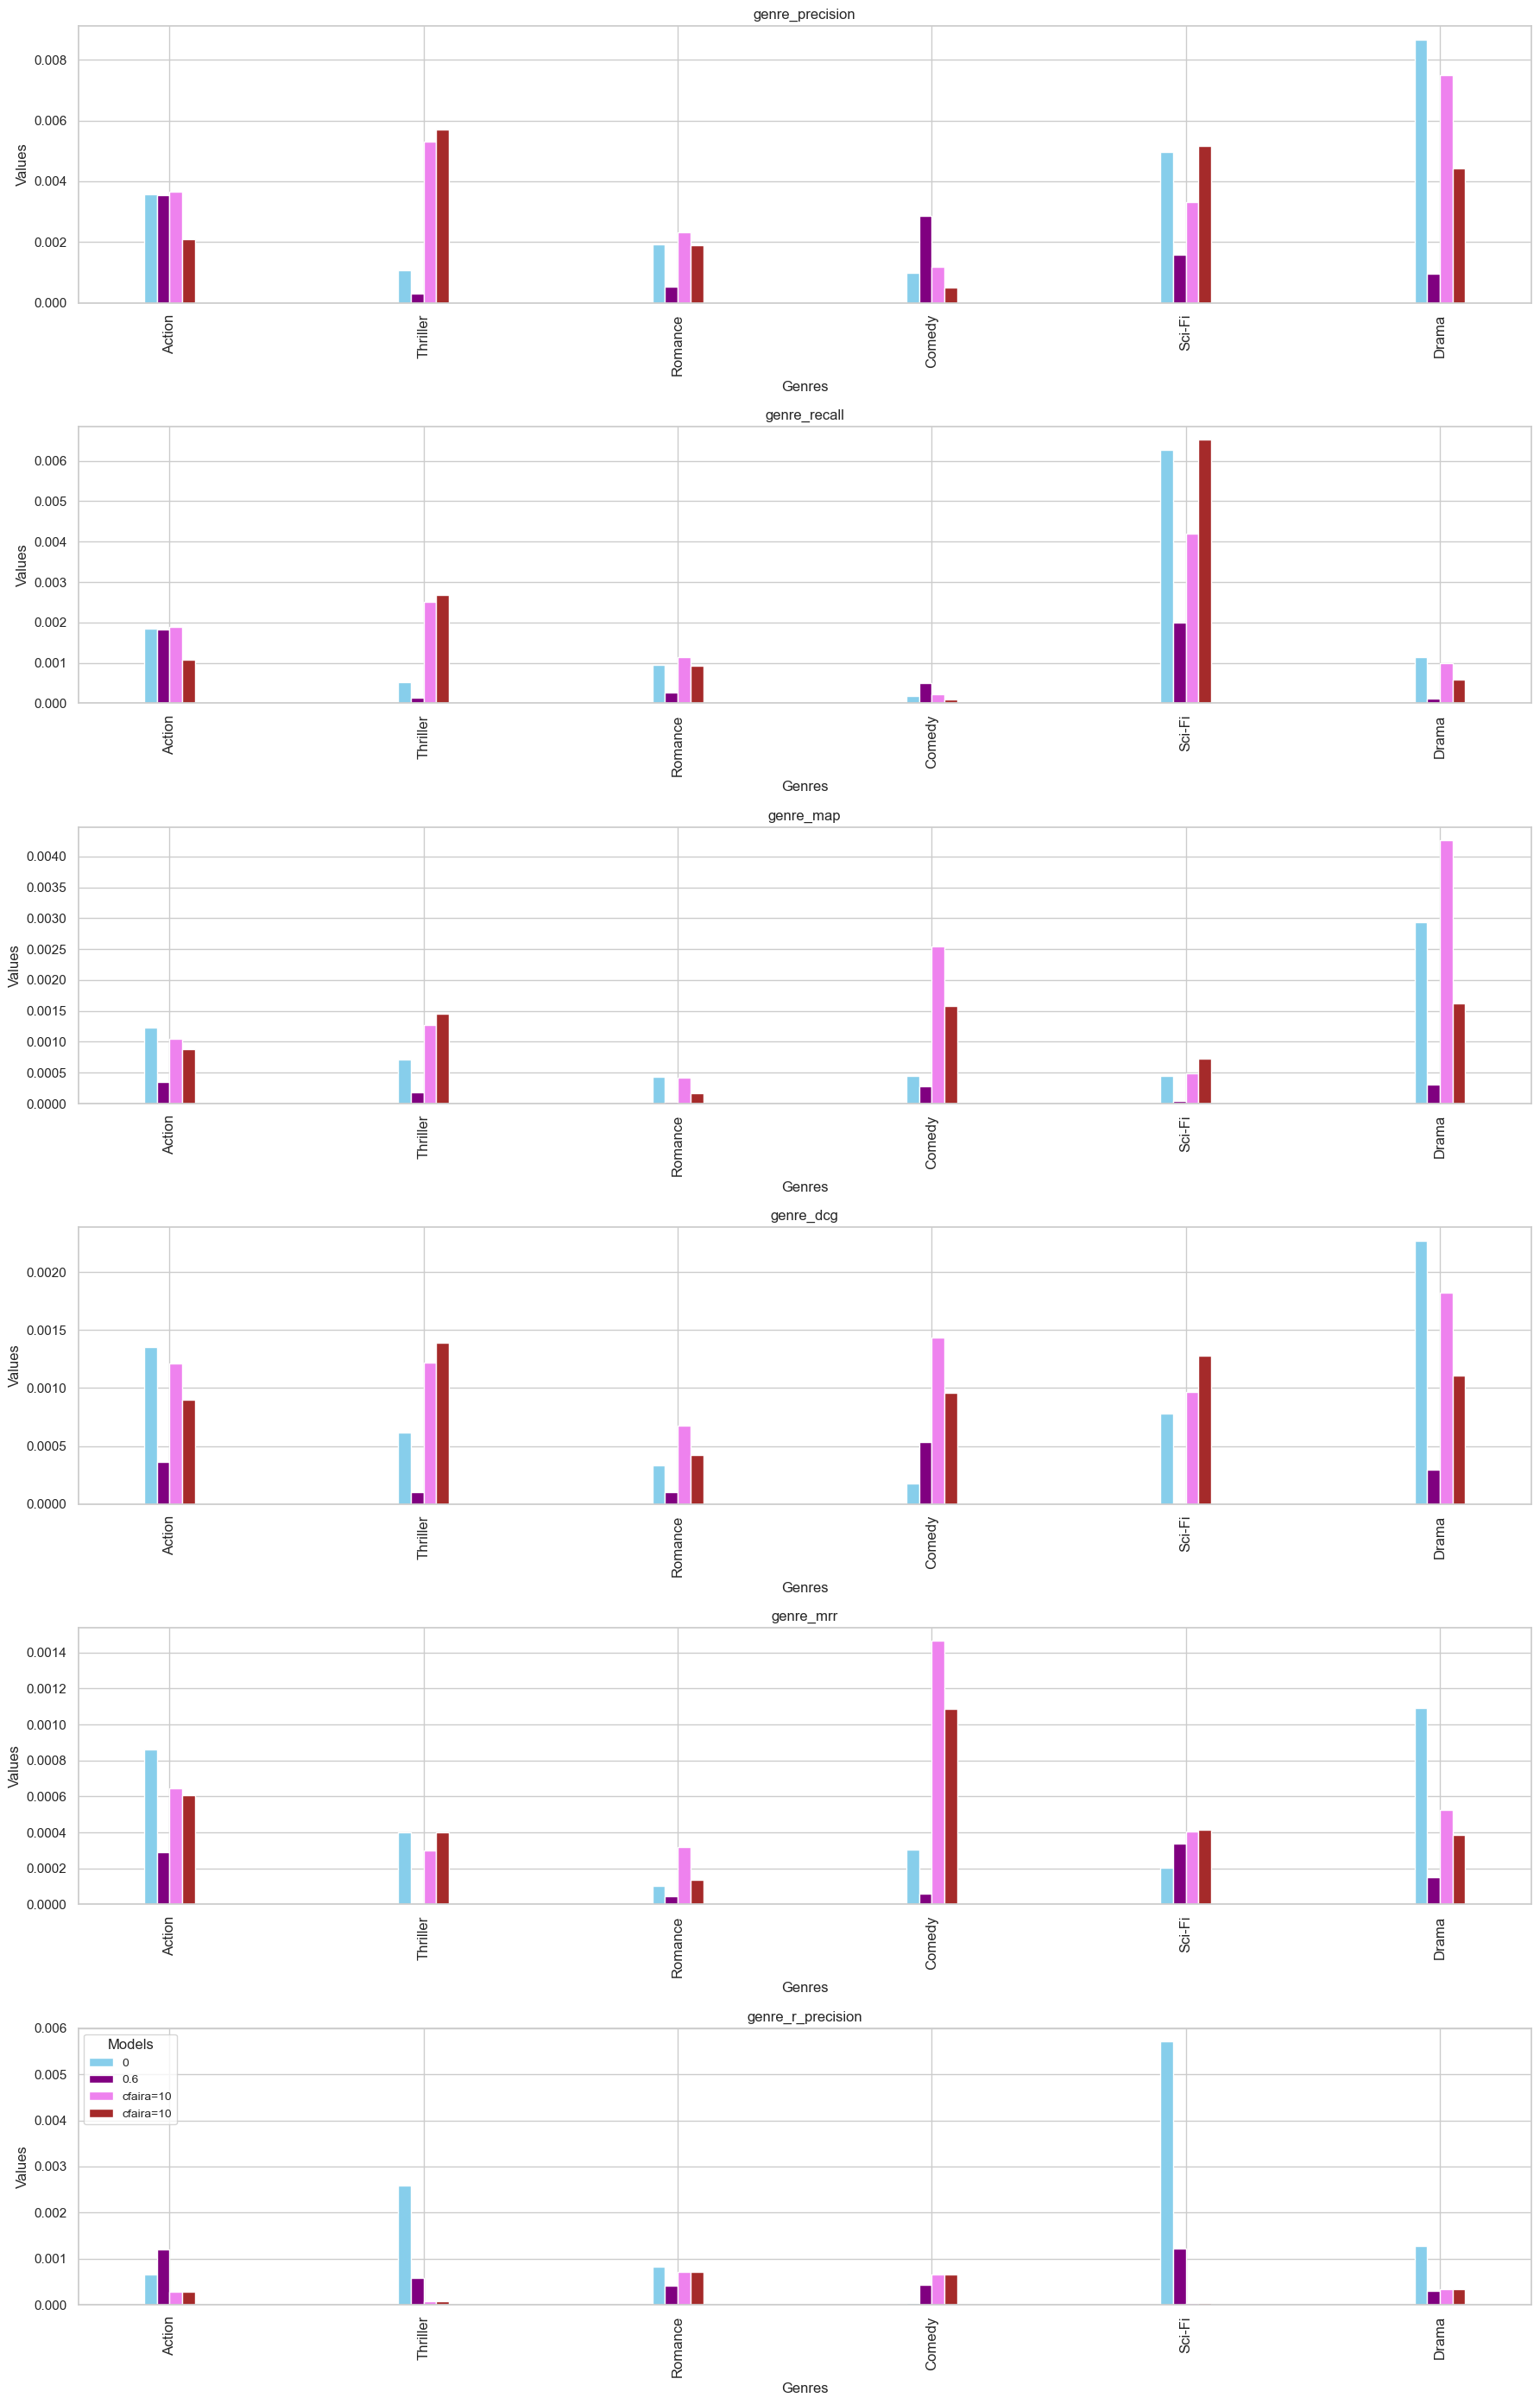

In [56]:


import matplotlib.pyplot as plt
import numpy as np


matrices = [
    model_gps[0][indices],
    model_grs[0][indices],
    model_gms[0][indices],
    model_gdcgs[0][indices],
    model_gmrrs[0][indices],
    model_grps[0][indices],
]
# matrices_2 = [
#     model_gps[1][indices],
#     model_grs[1][indices],
#     model_gms[1][indices],
#     model_gdcgs[1][indices],
#     model_gmrrs[1][indices],
#     model_grps[1][indices],
# ]
# matrices_3 = [
#     model_gps[2][indices],
#     model_grs[2][indices],
#     model_gms[2][indices],
#     model_gdcgs[2][indices],
#     model_gmrrs[2][indices],
#     model_grps[2][indices],
# ]
# matrices_4 = [
#     model_gps[3][indices],
#     model_grs[3][indices],
#     model_gms[3][indices],
#     model_gdcgs[3][indices],
#     model_gmrrs[3][indices],
#     model_grps[3][indices],
# ]
# matrices_5 = [
#     model_gps[4][indices],
#     model_grs[4][indices],
#     model_gms[4][indices],
#     model_gdcgs[4][indices],
#     model_gmrrs[4][indices],
#     model_grps[4][indices],
# ]
# matrices_6 = [
#     model_gps[5][indices],
#     model_grs[5][indices],
#     model_gms[5][indices],
#     model_gdcgs[5][indices],
#     model_gmrrs[5][indices],
#     model_grps[5][indices],
# ]
matrices_7 = [
    model_gps[6][indices],
    model_grs[6][indices],
    model_gms[6][indices],
    model_gdcgs[6][indices],
    model_gmrrs[6][indices],
    model_grps[6][indices],
]
# matrices_8 = [
#     model_gps[7][indices],
#     model_grs[7][indices],
#     model_gms[7][indices],
#     model_gdcgs[7][indices],
#     model_gmrrs[7][indices],
#     model_grps[7][indices],
# ]
# matrices_9 = [
#     model_gps[8][indices],
#     model_grs[8][indices],
#     model_gms[8][indices],
#     model_gdcgs[8][indices],
#     model_gmrrs[8][indices],
#     model_grps[8][indices],
# ]
# matrices_10 = [
#     model_gps[9][indices],
#     model_grs[9][indices],
#     model_gms[9][indices],
#     model_gdcgs[9][indices],
#     model_gmrrs[9][indices],
#     model_grps[9][indices],
# ]
# matrices_11 = [
#     model_gps[10][indices],
#     model_grs[10][indices],
#     model_gms[10][indices],
#     model_gdcgs[10][indices],
#     model_gmrrs[10][indices],
#     model_grps[10][indices],
# ]
# matrices_12 = [
#     cf_gp[indices],
#     cf_gr[indices],
#     cf_gm[indices],
#     cf_gndcg[indices],
#     cf_gmrr[indices],
#     model_grps[10][indices],
# ]
matrices_13 = [
    cf_gp[indices],
    cf_gr[indices],
    cf_gm[indices],
    cf_gndcg[indices],
    cf_gmrr[indices],
    model_grps[10][indices],
]
matrices_14 = [
    cf_gp_10[indices],
    cf_gr_10[indices],
    cf_gm_10[indices],
    cf_gndcg_10[indices],
    cf_gmrr_10[indices],
    model_grps[10][indices],
]



# matrices_2 = [
#     model_gp_2,
#     model_gr_2,
#     model_gm_2,
#     model_gdcg_2,
#     model_gmrr_2,
#     model_grp_2,
# ]
# matrices_3 = [
#     model_gp_3,
#     model_gr_3,
#     model_gm_3,
#     model_gdcg_3,
#     model_gmrr_3,
#     model_grp_3,
# ]

# values2 = matrices[1]
labels = compare_genres
# bar_width = 0.20
titles = [
    "genre_precision",
    "genre_recall",
    "genre_map",
    "genre_dcg",
    "genre_mrr",
    "genre_r_precision",
]


fig, axs = plt.subplots(6, 1, figsize=(18, 28))
axs = axs.flatten()
x = np.arange(len(compare_genres))  # the label locations
bar_width = 0.05  # the width of the bars
# rects1 = ax.bar(x - 3*bar_width/2, gender_genre_weights_topk_recom.iloc[0]*100, bar_width, label='Female (Top 50)', color="#bca0dc")


for i in range(len(titles)):
    axs[i].bar(
        x - 3 * bar_width / 2, abs(matrices[i]), bar_width, color="skyblue", label=alpha_values[0]
    )
    
    axs[i].bar(
        x -1 * bar_width / 2, abs(matrices_7[i]), bar_width, color="purple", label=alpha_values[6]
    )
    
    axs[i].bar(
        x + 1 * bar_width / 2, abs(matrices_13[i]), bar_width, color="violet", label="cfaira=10"
    )
    axs[i].bar(
        x + 3 * bar_width / 2, abs(matrices_14[i]), bar_width, color="brown", label="cfaira=10"
    )
    
    # axs[i].bar(x+2*bar_width/2, matrices_3[i], bar_width,color="green")
    # axs[i].bar(labels, matrices_2[i], color="skyblue")
    axs[i].set_xticks(x)
    axs[i].set_xticklabels(compare_genres, rotation=90, fontsize=12)

    axs[i].set_title(titles[i])
    axs[i].set_xlabel("Genres")
    axs[i].set_ylabel("Values")
    axs[i].tick_params(axis="x", rotation=90)

# plt.legend(loc='upper left', fontsize='small', title='Groups')

handles, labels = axs[0].get_legend_handles_labels()
print(labels)
print(handles)
plt.legend(handles, labels, loc="upper left", fontsize="small", title="Models")

# Adjust layout
plt.tight_layout()
plt.savefig("all_res.pdf" , format="pdf")
plt.show()

###################
# a*gender_loss + (1-a)*mseloss
# genderloss * batch_size * 25
###################

In [44]:
from operator import itemgetter

# unique_genres
indices = [0, 1, 2,9, 11, 17]
compare_genres = itemgetter(*indices)(unique_genres)
# compare_genres = unique_genres
# indices = range(18)
list(compare_genres)

['Action', 'Thriller', 'Romance', 'Comedy', 'Sci-Fi', 'Drama']

In [61]:
sum(abs(cf_gmrr) )> gmrr_sum

array([ True,  True, False,  True,  True,  True,  True,  True,  True,
        True,  True])

In [57]:
gp_sum

[0.03015047108778454,
 0.03223748291509486,
 0.034010172580321824,
 0.025276128514934482,
 0.030750919395695457,
 0.02456337725292949,
 0.015047578955041663,
 0.009851785030889534,
 0.008645020319647203,
 0.008493987935778956,
 0.006976698922967548]

In [36]:
truncated_pd_rank = [645 ,742 , 60 ,130 ,175, 489,  98, 115, 157, 866 ,710, 941 ,289 ,  1 ,495 , 51, 133 ,604,
                    95, 274]
gt_pos = [403, 139, 157]
truncated_pd_rank = gt_pos[:10]

ranked_scores = np.in1d(truncated_pd_rank, gt_pos).astype(int)
gain = 2**ranked_scores - 1
discounts = np.log2(np.arange(len(ranked_scores)) + 2)

np.sum(gain / discounts)

2.1309297535714578

In [38]:
0.3/2.13

0.14084507042253522

In [28]:
new_pd = pd.merge(movies,rating_data_pd, on="itemID")
new_pd = pd.merge(new_pd, users, on="userID")

In [38]:
import pandas as pd

# Assuming your dataframe is named df

# List of genre columns
genre_columns = unique_genres

# Separate data for gender 0 and 1
gender_0 = new_pd[new_pd['Gender'] == 0]
gender_1 = new_pd[new_pd['Gender'] == 1]

# Function to compute average rating for each genre
def compute_avg_rating(df, genre_columns):
    avg_ratings = {}
    
    for genre in genre_columns:
        # For each genre, calculate total rating where the genre is 1
        total_rating = (df[genre] * df['Rating']).sum()
        
        # Calculate count of movies in that genre
        count = df[genre].sum()
        # Avoid division by zero
        avg_rating = total_rating / count if count > 0 else 0
        avg_ratings[genre] = avg_rating
        
    return avg_ratings

# Calculate average rating for each genre for each gender
avg_ratings_gender_0 = compute_avg_rating(gender_0, genre_columns)
avg_ratings_gender_1 = compute_avg_rating(gender_1, genre_columns)

# Create a DataFrame to present the result
avg_ratings_df = pd.DataFrame({
    'Genre': genre_columns,
    'Average Rating (Gender 0)': [avg_ratings_gender_0[genre] for genre in genre_columns],
    'Average Rating (Gender 1)': [avg_ratings_gender_1[genre] for genre in genre_columns]
})

print(avg_ratings_df)


          Genre  Average Rating (Gender 0)  Average Rating (Gender 1)
0        Action                   3.481128                   3.488394
1      Thriller                   3.514806                   3.502174
2       Romance                   3.609222                   3.663806
3       Western                   3.639433                   3.521622
4    Children's                   3.320438                   3.428443
5       Mystery                   3.665139                   3.564885
6       Fantasy                   3.219512                   3.207756
7     Film-Noir                   3.976119                   3.756545
8   Documentary                   3.713235                   3.700599
9        Comedy                   3.386185                   3.431821
10    Adventure                   3.499575                   3.518153
11       Sci-Fi                   3.577373                   3.497336
12       Horror                   3.304729                   3.278716
13        Crime     

In [37]:
new_pd.groupby(new_pd["Gender"])[unique_genres].sum()

,Action,Thriller,Romance,Western,Children's,Mystery,Fantasy,Film-Noir,Documentary,Comedy,Adventure,Sci-Fi,Horror,Crime,Musical,War,Animation,Drama
Gender,,,,,,,,,,,,,,,,,,
0,20109,16750,13555,1481,4937,3927,984,1340,544,21658,10599,10094,4102,6232,3511,7200,2610,28655
1,5428,5060,5827,370,2229,1310,361,382,167,8001,3140,2628,1184,1778,1442,2184,995,10849


In [39]:
movies_df

NameError: name 'movies_df' is not defined

In [47]:
movies_df = movies[unique_genres].div(movies[unique_genres].sum(axis=1), axis=0)
movies_df = movies_df[unique_genres].sum()
movies_df

Action          96.966667
Thriller       105.933333
Romance        101.850000
Western         16.250000
Children's      49.050000
Mystery         23.283333
Fantasy          5.766667
Film-Noir        7.833333
Documentary     25.000000
Comedy         282.000000
Adventure       50.133333
Sci-Fi          39.500000
Horror          55.266667
Crime           39.450000
Musical         23.816667
War             27.566667
Animation       16.550000
Drama          381.783333
dtype: float64